#Data exploration and cleaning

##Import libraries

In [ ]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
!pip install dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 4.2 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import math
import graphviz
import statsmodels.api as sm
import shap
import xgboost as xgb

from imblearn.over_sampling import SMOTE

from IPython.display import Image

from scipy.stats import randint

from sklearn import tree
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, mean_absolute_error, roc_curve, roc_auc_score, f1_score, classification_report, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV, GridSearchCV, cross_val_predict
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.svm import SVR
from sklearn.tree import export_graphviz, DecisionTreeRegressor, export_text, plot_tree


from statsmodels.stats.outliers_influence import variance_inflation_factor

##Set working directory

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.chdir("/content/drive/MyDrive/DSBA 6211 - Group 5/Criminal Offenses within CMPD Jurisdiction")

##Create dataframes

In [ ]:
df_CMPD = pd.read_csv("CMPD_Incidents.csv")
df_unemployment = pd.read_csv("Unemployment Rate - 2017 to 2024 (FRED).csv")
df_NIBRS = pd.read_csv("NIBRS Offense Codes.csv")
df_NPA = pd.read_csv("NPA_Pop_Age_Income.csv")

##CMPD

###Detect Outliers

In [ ]:
outliers_count = {}

for col in df_CMPD.columns:
    if df_CMPD[col].dtype == 'object':
        category_counts = df_CMPD[col].value_counts()
        mean_count = category_counts.mean()
        std_count = category_counts.std()
        threshold = mean_count + 2 * std_count
        outliers = category_counts[category_counts > threshold]
        outliers_count[col] = len(outliers)
    else:
        mean_value = df_CMPD[col].mean()
        std_value = df_CMPD[col].std()
        threshold = mean_value + 2 * std_value
        outliers = df_CMPD[df_CMPD[col] > threshold]
        outliers_count[col] = len(outliers)

print("Outlier counts for each variable:")
for col, count in outliers_count.items():
    print(col, ":", count)

Outlier counts for each variable:
X : 6531
Y : 8267
YEAR : 0
INCIDENT_REPORT_ID : 0
LOCATION : 753
CITY : 1
STATE : 0
ZIP : 31
X_COORD_PUBLIC : 6531
Y_COORD_PUBLIC : 8267
LATITUDE_PUBLIC : 0
LONGITUDE_PUBLIC : 6668
DIVISION_ID : 0
CMPD_PATROL_DIVISION : 0
NPA : 305
DATE_REPORTED : 40
DATE_INCIDENT_BEGAN : 7
DATE_INCIDENT_END : 0
ADDRESS_DESCRIPTION : 0
LOCATION_TYPE_DESCRIPTION : 0
PLACE_TYPE_DESCRIPTION : 0
PLACE_DETAIL_DESCRIPTION : 3
CLEARANCE_STATUS : 0
CLEARANCE_DETAIL_STATUS : 1
CLEARANCE_DATE : 23
HIGHEST_NIBRS_CODE : 5
HIGHEST_NIBRS_DESCRIPTION : 5
OBJECTID : 0
GlobalID : 0


###Dataframe head

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df_CMPD.head()

,X,Y,YEAR,INCIDENT_REPORT_ID,LOCATION,CITY,STATE,ZIP,X_COORD_PUBLIC,Y_COORD_PUBLIC,LATITUDE_PUBLIC,LONGITUDE_PUBLIC,DIVISION_ID,CMPD_PATROL_DIVISION,NPA,DATE_REPORTED,DATE_INCIDENT_BEGAN,DATE_INCIDENT_END,ADDRESS_DESCRIPTION,LOCATION_TYPE_DESCRIPTION,PLACE_TYPE_DESCRIPTION,PLACE_DETAIL_DESCRIPTION,CLEARANCE_STATUS,CLEARANCE_DETAIL_STATUS,CLEARANCE_DATE,HIGHEST_NIBRS_CODE,HIGHEST_NIBRS_DESCRIPTION,OBJECTID,GlobalID
0,1430377.0,536012.0000,2024,20240222-2150-02,4400 W TYVOLA RD,CHARLOTTE,NC,28208.0,1430377.0,536012.0,35.207758,-80.907097,26,Westover,159,2024/02/22 00:00:00+00,2024/02/22 00:00:00+00,NaN,Location of occurrence,Outdoors,Open Area,Street/Highway,Open,Open,NaN,899,Other Unlisted Non-Criminal,1,{EF6A2E3A-27A0-4EBF-87E1-739D3711FC0F}
1,1440551.0,570638.0000,2024,20240222-2137-00,1500 PEACHTREE RD,CHARLOTTE,NC,NaN,1440551.0,570638.0,35.303414,-80.875232,11,North,49,2024/02/22 00:00:00+00,2024/02/22 00:00:00+00,2024/02/22 00:00:00+00,Location of occurrence,Indoors,Residential,Private Residence,Open,Open,NaN,800,Missing Person,2,{315FA086-8E70-4A90-A6C7-FD8C50DA4278}
2,1483444.0,562184.9998,2024,20240222-2043-00,8500 UNIVERSITY EAST DR,CHARLOTTE,NC,28213.0,1483444.0,562185.0,35.282332,-80.730994,14,University City,192,2024/02/22 00:00:00+00,2024/02/22 00:00:00+00,NaN,Location of occurrence,Outdoors,Residential,Private Residence,Open,Open,NaN,23H,All Other Thefts,3,{974709AF-7604-4315-8B60-4EEB22397CF8}
3,1451120.0,534293.9998,2024,20240222-2006-01,1000 BLYTHE BV,CHARLOTTE,NC,28203.0,1451120.0,534294.0,35.204113,-80.837559,16,Providence,3,2024/02/22 00:00:00+00,2024/02/22 00:00:00+00,2024/02/22 00:00:00+00,Location of occurrence,Parking Deck,Public/Non-Residential,Hospital/Medical Facility,Open,Open,NaN,290,Damage/Vandalism Of Property,4,{DF02E49A-531A-4A7E-B892-454E62D28298}
4,1486926.0,523499.0001,2024,20240222-2005-01,9100 ST MICHAELS LN,CHARLOTTE,NC,NaN,1486926.0,523499.0,35.176218,-80.717086,17,Independence,144,2024/02/22 00:00:00+00,2024/02/08 00:00:00+00,2024/02/22 00:00:00+00,Location where officer took report,Indoors,Residential,Private Residence,Open,Open,NaN,800,Missing Person,5,{DE365C19-E96C-4E31-B470-E1B15B6AAA64}


###Dataframe description

In [ ]:
df_CMPD.describe(include = 'all')

,X,Y,YEAR,INCIDENT_REPORT_ID,LOCATION,CITY,STATE,ZIP,X_COORD_PUBLIC,Y_COORD_PUBLIC,LATITUDE_PUBLIC,LONGITUDE_PUBLIC,DIVISION_ID,CMPD_PATROL_DIVISION,NPA,DATE_REPORTED,DATE_INCIDENT_BEGAN,DATE_INCIDENT_END,ADDRESS_DESCRIPTION,LOCATION_TYPE_DESCRIPTION,PLACE_TYPE_DESCRIPTION,PLACE_DETAIL_DESCRIPTION,CLEARANCE_STATUS,CLEARANCE_DETAIL_STATUS,CLEARANCE_DATE,HIGHEST_NIBRS_CODE,HIGHEST_NIBRS_DESCRIPTION,OBJECTID,GlobalID
count,6.385930e+05,638593.000000,662923.000000,662923,662923,662923,662917,450895.0,6.385930e+05,638593.000000,638593.000000,638593.000000,662923,661961,662923.000000,662923,662923,498857,662920,662922,662923,662923,662923,662923,268269,662923,662923,662923.000000,662923
unique,NaN,NaN,NaN,662923,47158,73,4,883.0,NaN,NaN,NaN,NaN,26,17,NaN,2609,4072,3421,2,5,5,82,5,12,2615,72,72,NaN,662923
top,NaN,NaN,NaN,20240222-2150-02,5500 JOSH BIRMINGHAM PY,CHARLOTTE,NC,28208.0,NaN,NaN,NaN,NaN,14,University City,NaN,2020/08/03 00:00:00+00,2019/01/01 00:00:00+00,2018/12/31 00:00:00+00,Location of occurrence,Indoors,Residential,Private Residence,Open,Open,2019/01/03 00:00:00+00,23F,Theft From Motor Vehicle,NaN,{EF6A2E3A-27A0-4EBF-87E1-739D3711FC0F}
freq,NaN,NaN,NaN,1,7223,661184,662909,27138.0,NaN,NaN,NaN,NaN,74334,74334,NaN,367,525,283,619560,292902,307664,156514,395734,394635,190,66894,66894,NaN,1
mean,1.453796e+06,541383.397007,2020.106813,NaN,NaN,NaN,NaN,NaN,1.453796e+06,541383.397006,35.219338,-80.829026,NaN,NaN,206.199248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,331462.000000,NaN
std,2.227753e+04,25196.772232,2.082228,NaN,NaN,NaN,NaN,NaN,2.227753e+04,25196.772232,0.715135,0.074236,NaN,NaN,124.769331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,191369.530589,NaN
min,1.384868e+06,465419.000100,2017.000000,NaN,NaN,NaN,NaN,NaN,1.384868e+06,465419.000000,-80.963592,-81.055885,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,1.438302e+06,525439.999800,2018.000000,NaN,NaN,NaN,NaN,NaN,1.438302e+06,525440.000000,35.179949,-80.880565,NaN,NaN,96.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165731.500000,NaN
50%,1.451996e+06,542034.000100,2020.000000,NaN,NaN,NaN,NaN,NaN,1.451996e+06,542034.000000,35.225438,-80.834969,NaN,NaN,200.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,331462.000000,NaN
75%,1.471843e+06,558332.000000,2022.000000,NaN,NaN,NaN,NaN,NaN,1.471843e+06,558332.000000,35.270289,-80.769082,NaN,NaN,331.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,497192.500000,NaN


### Dataframe info

In [ ]:
df_CMPD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662923 entries, 0 to 662922
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   X                          638593 non-null  float64
 1   Y                          638593 non-null  float64
 2   YEAR                       662923 non-null  int64  
 3   INCIDENT_REPORT_ID         662923 non-null  object 
 4   LOCATION                   662923 non-null  object 
 5   CITY                       662923 non-null  object 
 6   STATE                      662917 non-null  object 
 7   ZIP                        450895 non-null  object 
 8   X_COORD_PUBLIC             638593 non-null  float64
 9   Y_COORD_PUBLIC             638593 non-null  float64
 10  LATITUDE_PUBLIC            638593 non-null  float64
 11  LONGITUDE_PUBLIC           638593 non-null  float64
 12  DIVISION_ID                662923 non-null  object 
 13  CMPD_PATROL_DIVISION       66

###Add columns

In [ ]:
df_CMPD['DATE_REPORTED'] = pd.to_datetime(df_CMPD['DATE_REPORTED'])

df_CMPD['YEAR'] = df_CMPD['DATE_REPORTED'].dt.strftime('%Y')
df_CMPD['MONTH'] = df_CMPD['DATE_REPORTED'].dt.strftime('%m')
df_CMPD['DAY'] = df_CMPD['DATE_REPORTED'].dt.strftime('%d')

def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Winter'

df_CMPD['SEASON'] = df_CMPD['DATE_REPORTED'].dt.month.map(get_season)

###Remove "Location where officer took report"


In [ ]:
unique_ADDRESS_DESCRIPTION = df_CMPD['ADDRESS_DESCRIPTION'].unique()
unique_ADDRESS_DESCRIPTION

array(['Location of occurrence', 'Location where officer took report',
       nan], dtype=object)

In [ ]:
unique_ADDRESS_DESCRIPTION_counts = df_CMPD['ADDRESS_DESCRIPTION'].value_counts()
print(unique_ADDRESS_DESCRIPTION_counts)

ADDRESS_DESCRIPTION
Location of occurrence                619560
Location where officer took report     43360
Name: count, dtype: int64


In [ ]:
df_CMPD = df_CMPD[df_CMPD['ADDRESS_DESCRIPTION'] != "Location where officer took report"]
unique_ADDRESS_DESCRIPTION_counts = df_CMPD['ADDRESS_DESCRIPTION'].value_counts()

###Drop columns

In [ ]:
columns_to_drop = ['X', 'Y', 'INCIDENT_REPORT_ID', 'LOCATION', 'CITY', 'STATE',
                   'ZIP', 'X_COORD_PUBLIC', 'Y_COORD_PUBLIC', 'LATITUDE_PUBLIC', 'LONGITUDE_PUBLIC',
                   'DIVISION_ID', 'DATE_INCIDENT_BEGAN', 'DATE_INCIDENT_END', 'ADDRESS_DESCRIPTION',
                   'CLEARANCE_STATUS', 'CLEARANCE_DETAIL_STATUS', 'CLEARANCE_DATE', 'HIGHEST_NIBRS_DESCRIPTION',
                   'OBJECTID', 'GlobalID']
df_CMPD = df_CMPD.drop(columns=columns_to_drop)

###Remove non-criminal offenses

In [ ]:
df_CMPD = df_CMPD[df_CMPD['HIGHEST_NIBRS_CODE'].notna()]
df_CMPD = df_CMPD[~df_CMPD['HIGHEST_NIBRS_CODE'].str.startswith('8')]
unique_HIGHEST_NIBRS_CODE_counts = df_CMPD['HIGHEST_NIBRS_CODE'].value_counts()

###View nulls

In [ ]:
df_CMPD.isnull().sum()/len(df_CMPD)*100

,0
YEAR,0.000000
CMPD_PATROL_DIVISION,0.123130
NPA,0.000000
DATE_REPORTED,0.000000
LOCATION_TYPE_DESCRIPTION,0.000188
PLACE_TYPE_DESCRIPTION,0.000000
PLACE_DETAIL_DESCRIPTION,0.000000
HIGHEST_NIBRS_CODE,0.000000
MONTH,0.000000
DAY,0.000000


###Remove nulls

In [ ]:
df_CMPD_cleaned = df_CMPD.dropna()

##Unemployment

###Detect Outliers

In [ ]:
outliers_count = {}

for col in df_unemployment.columns:
    if df_unemployment[col].dtype == 'object':
        category_counts = df_unemployment[col].value_counts()
        mean_count = category_counts.mean()
        std_count = category_counts.std()
        threshold = mean_count + 2 * std_count
        outliers = category_counts[category_counts > threshold]
        outliers_count[col] = len(outliers)
    else:
        mean_value = df_unemployment[col].mean()
        std_value = df_unemployment[col].std()
        threshold = mean_value + 2 * std_value
        outliers = df_unemployment[df_unemployment[col] > threshold]
        outliers_count[col] = len(outliers)

print("Outlier counts for each variable:")
for col, count in outliers_count.items():
    print(col, ":", count)

Outlier counts for each variable:
UNRATE : 4
UNRATE_MONTH : 0
UNRATE_YEAR : 0
UNRATE_DATE : 0


###Dataframe head

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df_unemployment.head()

,UNRATE,UNRATE_MONTH,UNRATE_YEAR,UNRATE_DATE
0,4.7,1,2017,2017-01-01
1,4.6,2,2017,2017-02-01
2,4.4,3,2017,2017-03-01
3,4.4,4,2017,2017-04-01
4,4.4,5,2017,2017-05-01


###Dataframe description

In [ ]:
df_unemployment.describe(include = 'all')

,UNRATE,UNRATE_MONTH,UNRATE_YEAR,UNRATE_DATE
count,85.000000,85.000000,85.000000,85
unique,NaN,NaN,NaN,85
top,NaN,NaN,NaN,2017-01-01
freq,NaN,NaN,NaN,1
mean,4.649412,6.435294,2020.047059,NaN
std,2.033506,3.503220,2.046518,NaN
min,3.400000,1.000000,2017.000000,NaN
25%,3.600000,3.000000,2018.000000,NaN
50%,3.800000,6.000000,2020.000000,NaN
75%,4.400000,9.000000,2022.000000,NaN


###Dataframe info

In [ ]:
df_unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   UNRATE        85 non-null     float64
 1   UNRATE_MONTH  85 non-null     int64  
 2   UNRATE_YEAR   85 non-null     int64  
 3   UNRATE_DATE   85 non-null     object 
dtypes: float64(1), int64(2), object(1)
memory usage: 2.8+ KB


###Drop columns

In [ ]:
columns_to_drop = ['UNRATE_DATE']
df_unemployment = df_unemployment.drop(columns=columns_to_drop)

###View nulls

In [ ]:
df_unemployment.isnull().sum()/len(df_unemployment)*100

,0
UNRATE,0.0
UNRATE_MONTH,0.0
UNRATE_YEAR,0.0


###Remove nulls

In [ ]:
df_unemployment_cleaned = df_unemployment.dropna()

##NIBRS

###Detect Outliers

In [ ]:
outliers_count = {}

for col in df_NIBRS.columns:
    if df_NIBRS[col].dtype == 'object':
        category_counts = df_NIBRS[col].value_counts()
        mean_count = category_counts.mean()
        std_count = category_counts.std()
        threshold = mean_count + 2 * std_count
        outliers = category_counts[category_counts > threshold]
        outliers_count[col] = len(outliers)
    else:
        mean_value = df_NIBRS[col].mean()
        std_value = df_NIBRS[col].std()
        threshold = mean_value + 2 * std_value
        outliers = df_NIBRS[df_NIBRS[col] > threshold]
        outliers_count[col] = len(outliers)

print("Outlier counts for each variable:")
for col, count in outliers_count.items():
    print(col, ":", count)

Outlier counts for each variable:
GROUP_OFFENSES : 2
OFFENSE_CODE : 0
OFFENSE_DESCRIPTION : 0
CRIME_AGAINST : 0
GROUP : 0


###Dataframe head

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df_NIBRS.head()

,GROUP_OFFENSES,OFFENSE_CODE,OFFENSE_DESCRIPTION,CRIME_AGAINST,GROUP
0,Arson,200,Property,Property,A
1,Assault Offenses,13A,Aggravated Assault,Person,A
2,Assault Offenses,13B,Simple Assault,Person,A
3,Assault Offenses,13C,Intimidation,Person,A
4,Bribery,510,Bribery,Property,A


###Dataframe description

In [ ]:
df_NIBRS.describe(include = 'all')

,GROUP_OFFENSES,OFFENSE_CODE,OFFENSE_DESCRIPTION,CRIME_AGAINST,GROUP
count,57,57,57,57,57
unique,33,57,57,6,2
top,Larceny/Theft Offenses,200,Property,Property,A
freq,8,1,1,24,46


###Dataframe info

In [ ]:
df_NIBRS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   GROUP_OFFENSES       57 non-null     object
 1   OFFENSE_CODE         57 non-null     object
 2   OFFENSE_DESCRIPTION  57 non-null     object
 3   CRIME_AGAINST        57 non-null     object
 4   GROUP                57 non-null     object
dtypes: object(5)
memory usage: 2.4+ KB


###View nulls

In [ ]:
df_NIBRS.isnull().sum()/len(df_NPA)*100

,0
GROUP_OFFENSES,0.0
OFFENSE_CODE,0.0
OFFENSE_DESCRIPTION,0.0
CRIME_AGAINST,0.0
GROUP,0.0


###Remove nulls

In [ ]:
df_NIBRS_cleaned = df_NIBRS.dropna()

##NPA

###Detect Outliers

In [ ]:
outliers_count = {}

for col in df_NIBRS.columns:
    if df_NIBRS[col].dtype == 'object':
        category_counts = df_NIBRS[col].value_counts()
        mean_count = category_counts.mean()
        std_count = category_counts.std()
        threshold = mean_count + 2 * std_count
        outliers = category_counts[category_counts > threshold]
        outliers_count[col] = len(outliers)
    else:
        mean_value = df_NIBRS[col].mean()
        std_value = df_NIBRS[col].std()
        threshold = mean_value + 2 * std_value
        outliers = df_NIBRS[df_NIBRS[col] > threshold]
        outliers_count[col] = len(outliers)

print("Outlier counts for each variable:")
for col, count in outliers_count.items():
    print(col, ":", count)

Outlier counts for each variable:
GROUP_OFFENSES : 2
OFFENSE_CODE : 0
OFFENSE_DESCRIPTION : 0
CRIME_AGAINST : 0
GROUP : 0


###Dataframe head

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df_NPA.head()

,NPA,YEAR,TOTAL_POPULATION,PEOPLE_PER_ACRE,MEDIAN_AGE_OF_RESIDENT,MEDIAN_HOUSEHOLD_INCOME
0,2,2021,2143.0,5.0,31.0,45776.0
1,3,2021,12121.0,10.0,33.0,97294.0
2,4,2021,1168.0,4.0,43.0,156250.0
3,5,2021,772.0,5.0,33.0,22589.0
4,6,2021,1797.0,4.0,38.0,27381.0


###Dataframe description

In [ ]:
df_NPA.describe(include = 'all')

,NPA,YEAR,TOTAL_POPULATION,PEOPLE_PER_ACRE,MEDIAN_AGE_OF_RESIDENT,MEDIAN_HOUSEHOLD_INCOME
count,1848.000000,1848.000000,1820.000000,1804.000000,1812.000000,1728.000000
mean,235.850649,2020.500000,2412.507692,5.097561,37.417219,69348.943287
std,135.811254,1.118337,1393.078691,3.299005,7.385593,37145.992227
min,2.000000,2019.000000,297.000000,1.000000,19.000000,12476.000000
25%,119.000000,2019.750000,1497.000000,3.000000,32.000000,41367.000000
50%,235.500000,2020.500000,2143.000000,4.000000,36.000000,61568.000000
75%,352.000000,2021.250000,2858.000000,7.000000,42.000000,88906.000000
max,475.000000,2022.000000,12121.000000,26.000000,73.000000,250000.000000


###Dataframe info

In [ ]:
df_NPA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1848 entries, 0 to 1847
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NPA                      1848 non-null   int64  
 1   YEAR                     1848 non-null   int64  
 2   TOTAL_POPULATION         1820 non-null   float64
 3   PEOPLE_PER_ACRE          1804 non-null   float64
 4   MEDIAN_AGE_OF_RESIDENT   1812 non-null   float64
 5   MEDIAN_HOUSEHOLD_INCOME  1728 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 86.8 KB


###View nulls

In [ ]:
#df_NPA.isnull().sum()/len(df_NPA)*100
df_NPA.isnull().sum()

,0
NPA,0
YEAR,0
TOTAL_POPULATION,28
PEOPLE_PER_ACRE,44
MEDIAN_AGE_OF_RESIDENT,36
MEDIAN_HOUSEHOLD_INCOME,120


###Remove nulls

In [ ]:
df_NPA_cleaned = df_NPA.dropna()

##Combine dataframes

###Convert datatypes--this time for merging

In [ ]:
df_NPA_cleaned['NPA'] = df_NPA_cleaned['NPA'].astype(int)
df_NPA_cleaned[['YEAR']] = df_NPA_cleaned[['YEAR']].astype(int)
df_CMPD_cleaned['MONTH'] = df_CMPD_cleaned['MONTH'].astype(int)
df_CMPD_cleaned['YEAR'] = df_CMPD_cleaned['YEAR'].astype(int)

###Combine CMPD & Unemployment

In [ ]:
df_merged = pd.merge(df_CMPD_cleaned, df_unemployment_cleaned,
                     left_on=['MONTH', 'YEAR'],
                     right_on=['UNRATE_MONTH', 'UNRATE_YEAR'],
                     how='inner')

####Drop columns

In [ ]:
columns_to_drop = ['UNRATE_MONTH', 'UNRATE_YEAR']
df_merged = df_merged.drop(columns=columns_to_drop)

###Combine Merged & NIBRS

In [ ]:
df_merged = pd.merge(df_merged, df_NIBRS_cleaned,
                   left_on="HIGHEST_NIBRS_CODE",
                   right_on="OFFENSE_CODE",
                   how="left")

####Drop columns

In [ ]:
columns_to_drop = ['HIGHEST_NIBRS_CODE', 'OFFENSE_DESCRIPTION']
df_merged = df_merged.drop(columns=columns_to_drop)

###Combine Merged & NPA

In [ ]:
df_merged = pd.merge(df_merged, df_NPA_cleaned,
                     left_on=['NPA', 'YEAR'],
                     right_on=['NPA', 'YEAR'],
                     how='inner')

##Merged

###Dataframe head

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df_merged.head()

,YEAR,CMPD_PATROL_DIVISION,NPA,DATE_REPORTED,LOCATION_TYPE_DESCRIPTION,PLACE_TYPE_DESCRIPTION,PLACE_DETAIL_DESCRIPTION,MONTH,DAY,SEASON,UNRATE,GROUP_OFFENSES,OFFENSE_CODE,CRIME_AGAINST,GROUP,TOTAL_POPULATION,PEOPLE_PER_ACRE,MEDIAN_AGE_OF_RESIDENT,MEDIAN_HOUSEHOLD_INCOME
0,2022,Metro,361,2022-12-31 00:00:00+00:00,Outdoors,Open Area,Street/Highway,12,31,Winter,3.5,Assault Offenses,13B,Person,A,2061.0,4.0,29.0,44891.0
1,2022,Metro,361,2022-12-31 00:00:00+00:00,Outdoors,Open Area,Street/Highway,12,31,Winter,3.5,Larceny/Theft Offenses,23F,Property,A,2061.0,4.0,29.0,44891.0
2,2022,Metro,361,2022-12-30 00:00:00+00:00,Outdoors,Open Area,Street/Highway,12,30,Winter,3.5,Stolen Property Offenses,280,Property,A,2061.0,4.0,29.0,44891.0
3,2022,Metro,361,2022-12-30 00:00:00+00:00,Outdoors,Residential,Private Residence,12,30,Winter,3.5,Assault Offenses,13A,Person,A,2061.0,4.0,29.0,44891.0
4,2022,Metro,361,2022-12-28 00:00:00+00:00,Indoors,Retail,Convenience Store,12,28,Winter,3.5,Burglary/Breaking & Entering,220,Property,A,2061.0,4.0,29.0,44891.0


###Dataframe description

In [ ]:
df_merged.describe(include = 'all')

,YEAR,CMPD_PATROL_DIVISION,NPA,DATE_REPORTED,LOCATION_TYPE_DESCRIPTION,PLACE_TYPE_DESCRIPTION,PLACE_DETAIL_DESCRIPTION,MONTH,DAY,SEASON,UNRATE,GROUP_OFFENSES,OFFENSE_CODE,CRIME_AGAINST,GROUP,TOTAL_POPULATION,PEOPLE_PER_ACRE,MEDIAN_AGE_OF_RESIDENT,MEDIAN_HOUSEHOLD_INCOME
count,266427.000000,266427,266427.000000,266427,266427,266427,266427,266427.000000,266427,266427,266427.000000,263365,263365,263365,263365,266427.000000,266427.000000,266427.000000,266427.000000
unique,NaN,16,NaN,NaN,5,5,80,NaN,31,4,NaN,30,53,5,2,NaN,NaN,NaN,NaN
top,NaN,University City,NaN,NaN,Indoors,Residential,Private Residence,NaN,04,Summer,NaN,Larceny/Theft Offenses,23F,Property,A,NaN,NaN,NaN,NaN
freq,NaN,33284,NaN,NaN,112388,124494,60657,NaN,9025,69717,NaN,91104,31912,159399,227345,NaN,NaN,NaN,NaN
mean,2020.454432,NaN,198.211251,2020-12-15 18:21:55.893659392+00:00,NaN,NaN,NaN,6.568512,NaN,NaN,5.120233,NaN,NaN,NaN,NaN,3071.129172,5.465137,34.908478,52655.406505
min,2019.000000,NaN,2.000000,2019-01-01 00:00:00+00:00,NaN,NaN,NaN,1.000000,NaN,NaN,3.500000,NaN,NaN,NaN,NaN,297.000000,1.000000,19.000000,12476.000000
25%,2019.000000,NaN,87.000000,2019-12-04 00:00:00+00:00,NaN,NaN,NaN,4.000000,NaN,NaN,3.600000,NaN,NaN,NaN,NaN,1835.000000,3.000000,31.000000,31610.000000
50%,2020.000000,NaN,186.000000,2020-12-08 00:00:00+00:00,NaN,NaN,NaN,7.000000,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,2579.000000,5.000000,33.000000,45229.000000
75%,2021.000000,NaN,319.000000,2021-12-16 00:00:00+00:00,NaN,NaN,NaN,10.000000,NaN,NaN,6.100000,NaN,NaN,NaN,NaN,3588.000000,7.000000,39.000000,64703.000000
max,2022.000000,NaN,475.000000,2022-12-31 00:00:00+00:00,NaN,NaN,NaN,12.000000,NaN,NaN,14.800000,NaN,NaN,NaN,NaN,12121.000000,26.000000,63.000000,250000.000000


###Dataframe info

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266427 entries, 0 to 266426
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   YEAR                       266427 non-null  int64              
 1   CMPD_PATROL_DIVISION       266427 non-null  object             
 2   NPA                        266427 non-null  int64              
 3   DATE_REPORTED              266427 non-null  datetime64[ns, UTC]
 4   LOCATION_TYPE_DESCRIPTION  266427 non-null  object             
 5   PLACE_TYPE_DESCRIPTION     266427 non-null  object             
 6   PLACE_DETAIL_DESCRIPTION   266427 non-null  object             
 7   MONTH                      266427 non-null  int64              
 8   DAY                        266427 non-null  object             
 9   SEASON                     266427 non-null  object             
 10  UNRATE                     266427 non-null  float64     

###Rename columns

In [ ]:
df_merged = df_merged.rename(columns={'CMPD_PATROL_DIVISION': 'PATROL_DIVISION'})
df_merged = df_merged.rename(columns={'LOCATION_TYPE_DESCRIPTION': 'LOCATION'})
df_merged = df_merged.rename(columns={'PLACE_TYPE_DESCRIPTION': 'PLACE_TYPE'})
df_merged = df_merged.rename(columns={'PLACE_DETAIL_DESCRIPTION': 'PLACE_DETAIL'})
df_merged = df_merged.rename(columns={'CLEARANCE_DETAIL_STATUS': 'CLEARANCE_DETAIL'})
df_merged = df_merged.rename(columns={'HIGHEST_NIBRS_CODE': 'OFFENSE_CODE'})
df_merged = df_merged.rename(columns={'YEAR_REPORTED': 'YEAR'})
df_merged = df_merged.rename(columns={'MONTH_REPORTED': 'MONTH'})
df_merged = df_merged.rename(columns={'DAY_REPORTED': 'DAY'})
df_merged = df_merged.rename(columns={'SEASON_REPORTED': 'SEASON'})

###Reorder columns

In [ ]:
df_merged = df_merged[['DATE_REPORTED', 'YEAR', 'MONTH', 'DAY', 'SEASON'] + [col for col in df_merged.columns if col not in ['DATE_REPORTED', 'YEAR', 'MONTH', 'DAY', 'SEASON']]]

###View Nulls

In [ ]:
df_merged.isnull().sum()/len(df_CMPD)*100

,0
DATE_REPORTED,0.000000
YEAR,0.000000
MONTH,0.000000
DAY,0.000000
SEASON,0.000000
PATROL_DIVISION,0.000000
NPA,0.000000
LOCATION,0.000000
PLACE_TYPE,0.000000
PLACE_DETAIL,0.000000


###Remove nulls

In [ ]:
df_merged = df_merged.dropna()

###Add column

In [ ]:
df_merged['DATE_REPORTED'] = pd.to_datetime(df_merged['DATE_REPORTED'])
MONTHLY_CRIME_COUNT = df_merged.groupby([df_merged['DATE_REPORTED'].dt.year, df_merged['DATE_REPORTED'].dt.month]).size().rename('MONTHLY_CRIME_COUNT')
df_merged = df_merged.merge(MONTHLY_CRIME_COUNT, how='left', left_on=[df_merged['DATE_REPORTED'].dt.year, df_merged['DATE_REPORTED'].dt.month], right_index=True, suffixes=('', '_count'))
df_merged.reset_index(drop=True, inplace=True)

###Drop Column

In [ ]:
columns_to_drop = ['DATE_REPORTED']
df_merged = df_merged.drop(columns=columns_to_drop)

###Convert datatypes--this time for analysis

In [ ]:
df_merged['NPA'] = df_merged['NPA'].astype(str)
df_merged['MONTH'] = df_merged['MONTH'].astype(str)
df_merged['YEAR'] = df_merged['YEAR'].astype(str)

###Dataframe head

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df_merged.head()

,YEAR,MONTH,DAY,SEASON,PATROL_DIVISION,NPA,LOCATION,PLACE_TYPE,PLACE_DETAIL,UNRATE,GROUP_OFFENSES,OFFENSE_CODE,CRIME_AGAINST,GROUP,TOTAL_POPULATION,PEOPLE_PER_ACRE,MEDIAN_AGE_OF_RESIDENT,MEDIAN_HOUSEHOLD_INCOME,MONTHLY_CRIME_COUNT
0,2022,12,31,Winter,Metro,361,Outdoors,Open Area,Street/Highway,3.5,Assault Offenses,13B,Person,A,2061.0,4.0,29.0,44891.0,4997
1,2022,12,31,Winter,Metro,361,Outdoors,Open Area,Street/Highway,3.5,Larceny/Theft Offenses,23F,Property,A,2061.0,4.0,29.0,44891.0,4997
2,2022,12,30,Winter,Metro,361,Outdoors,Open Area,Street/Highway,3.5,Stolen Property Offenses,280,Property,A,2061.0,4.0,29.0,44891.0,4997
3,2022,12,30,Winter,Metro,361,Outdoors,Residential,Private Residence,3.5,Assault Offenses,13A,Person,A,2061.0,4.0,29.0,44891.0,4997
4,2022,12,28,Winter,Metro,361,Indoors,Retail,Convenience Store,3.5,Burglary/Breaking & Entering,220,Property,A,2061.0,4.0,29.0,44891.0,4997


###Dataframe description

In [ ]:
df_merged.describe(include = 'all')

,YEAR,MONTH,DAY,SEASON,PATROL_DIVISION,NPA,LOCATION,PLACE_TYPE,PLACE_DETAIL,UNRATE,GROUP_OFFENSES,OFFENSE_CODE,CRIME_AGAINST,GROUP,TOTAL_POPULATION,PEOPLE_PER_ACRE,MEDIAN_AGE_OF_RESIDENT,MEDIAN_HOUSEHOLD_INCOME,MONTHLY_CRIME_COUNT
count,263365,263365,263365,263365,263365,263365,263365,263365,263365,263365.000000,263365,263365,263365,263365,263365.000000,263365.000000,263365.000000,263365.000000,263365.000000
unique,4,12,31,4,16,407,5,5,80,NaN,30,53,5,2,NaN,NaN,NaN,NaN,NaN
top,2019,7,04,Summer,University City,371,Indoors,Residential,Private Residence,NaN,Larceny/Theft Offenses,23F,Property,A,NaN,NaN,NaN,NaN,NaN
freq,71147,23579,8913,69002,32854,5210,110573,122771,59667,NaN,91104,31912,159399,227345,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.122329,NaN,NaN,NaN,NaN,3069.824214,5.467553,34.904589,52597.101122,5518.532170
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.471123,NaN,NaN,NaN,NaN,2021.745950,3.434774,6.457034,28277.509487,417.483555
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.500000,NaN,NaN,NaN,NaN,297.000000,1.000000,19.000000,12476.000000,4597.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.600000,NaN,NaN,NaN,NaN,1835.000000,3.000000,31.000000,31610.000000,5252.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,2579.000000,5.000000,33.000000,45229.000000,5499.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.100000,NaN,NaN,NaN,NaN,3588.000000,7.000000,39.000000,64703.000000,5785.000000


###Dataframe info

###Detect Outliers

In [ ]:
outliers_count = {}

for col in df_merged.columns:
    if df_merged[col].dtype == 'object':
        category_counts = df_merged[col].value_counts()
        mean_count = category_counts.mean()
        std_count = category_counts.std()
        threshold = mean_count + 2 * std_count
        outliers = category_counts[category_counts > threshold]
        outliers_count[col] = len(outliers)
    else:
        mean_value = df_merged[col].mean()
        std_value = df_merged[col].std()
        threshold = mean_value + 2 * std_value
        outliers = df_merged[df_merged[col] > threshold]
        outliers_count[col] = len(outliers)

print("Outlier counts for each variable:")
for col, count in outliers_count.items():
    print(col, ":", count)

Outlier counts for each variable:
YEAR : 0
MONTH : 0
DAY : 0
SEASON : 0
PATROL_DIVISION : 0
NPA : 18
LOCATION : 0
PLACE_TYPE : 0
PLACE_DETAIL : 3
UNRATE : 20620
GROUP_OFFENSES : 2
OFFENSE_CODE : 4
CRIME_AGAINST : 0
GROUP : 0
TOTAL_POPULATION : 14202
PEOPLE_PER_ACRE : 10889
MEDIAN_AGE_OF_RESIDENT : 10316
MEDIAN_HOUSEHOLD_INCOME : 12807
MONTHLY_CRIME_COUNT : 6444


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263365 entries, 0 to 263364
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   YEAR                     263365 non-null  object 
 1   MONTH                    263365 non-null  object 
 2   DAY                      263365 non-null  object 
 3   SEASON                   263365 non-null  object 
 4   PATROL_DIVISION          263365 non-null  object 
 5   NPA                      263365 non-null  object 
 6   LOCATION                 263365 non-null  object 
 7   PLACE_TYPE               263365 non-null  object 
 8   PLACE_DETAIL             263365 non-null  object 
 9   UNRATE                   263365 non-null  float64
 10  GROUP_OFFENSES           263365 non-null  object 
 11  OFFENSE_CODE             263365 non-null  object 
 12  CRIME_AGAINST            263365 non-null  object 
 13  GROUP                    263365 non-null  object 
 14  TOTA

##Visualization

###Numerical Features

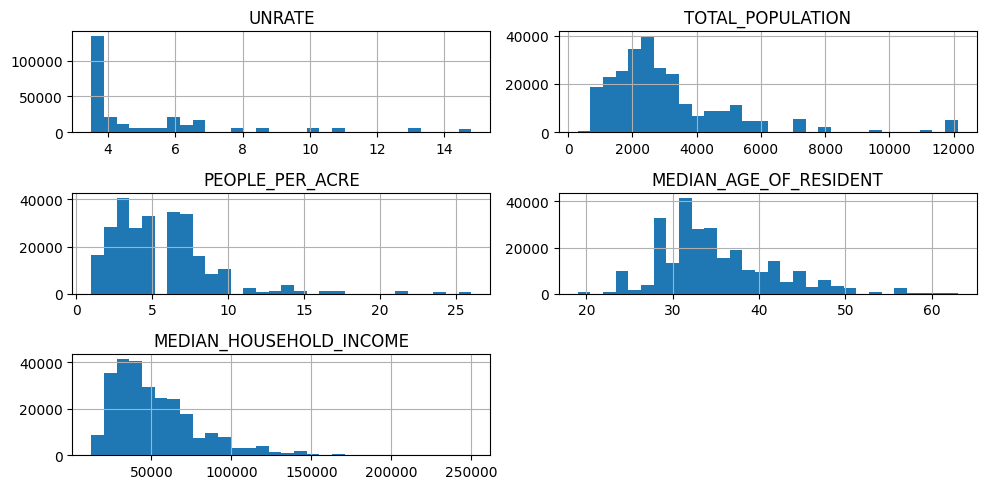

In [ ]:
numerical_features = ['UNRATE', 'TOTAL_POPULATION', 'PEOPLE_PER_ACRE','MEDIAN_AGE_OF_RESIDENT',
             'MEDIAN_HOUSEHOLD_INCOME']

df_merged[numerical_features].hist(bins=30, figsize=(10,5))
plt.tight_layout()
plt.show()

###Correlation Matrix

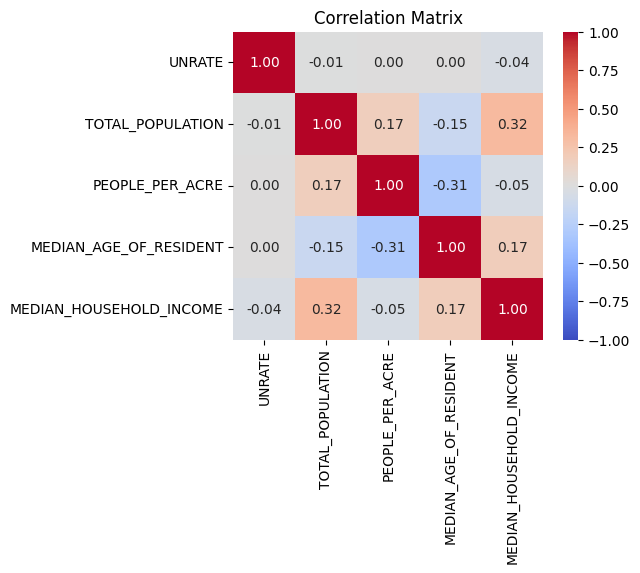

In [ ]:
correlation_matrix = df_merged[numerical_features].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

###Categorical Features

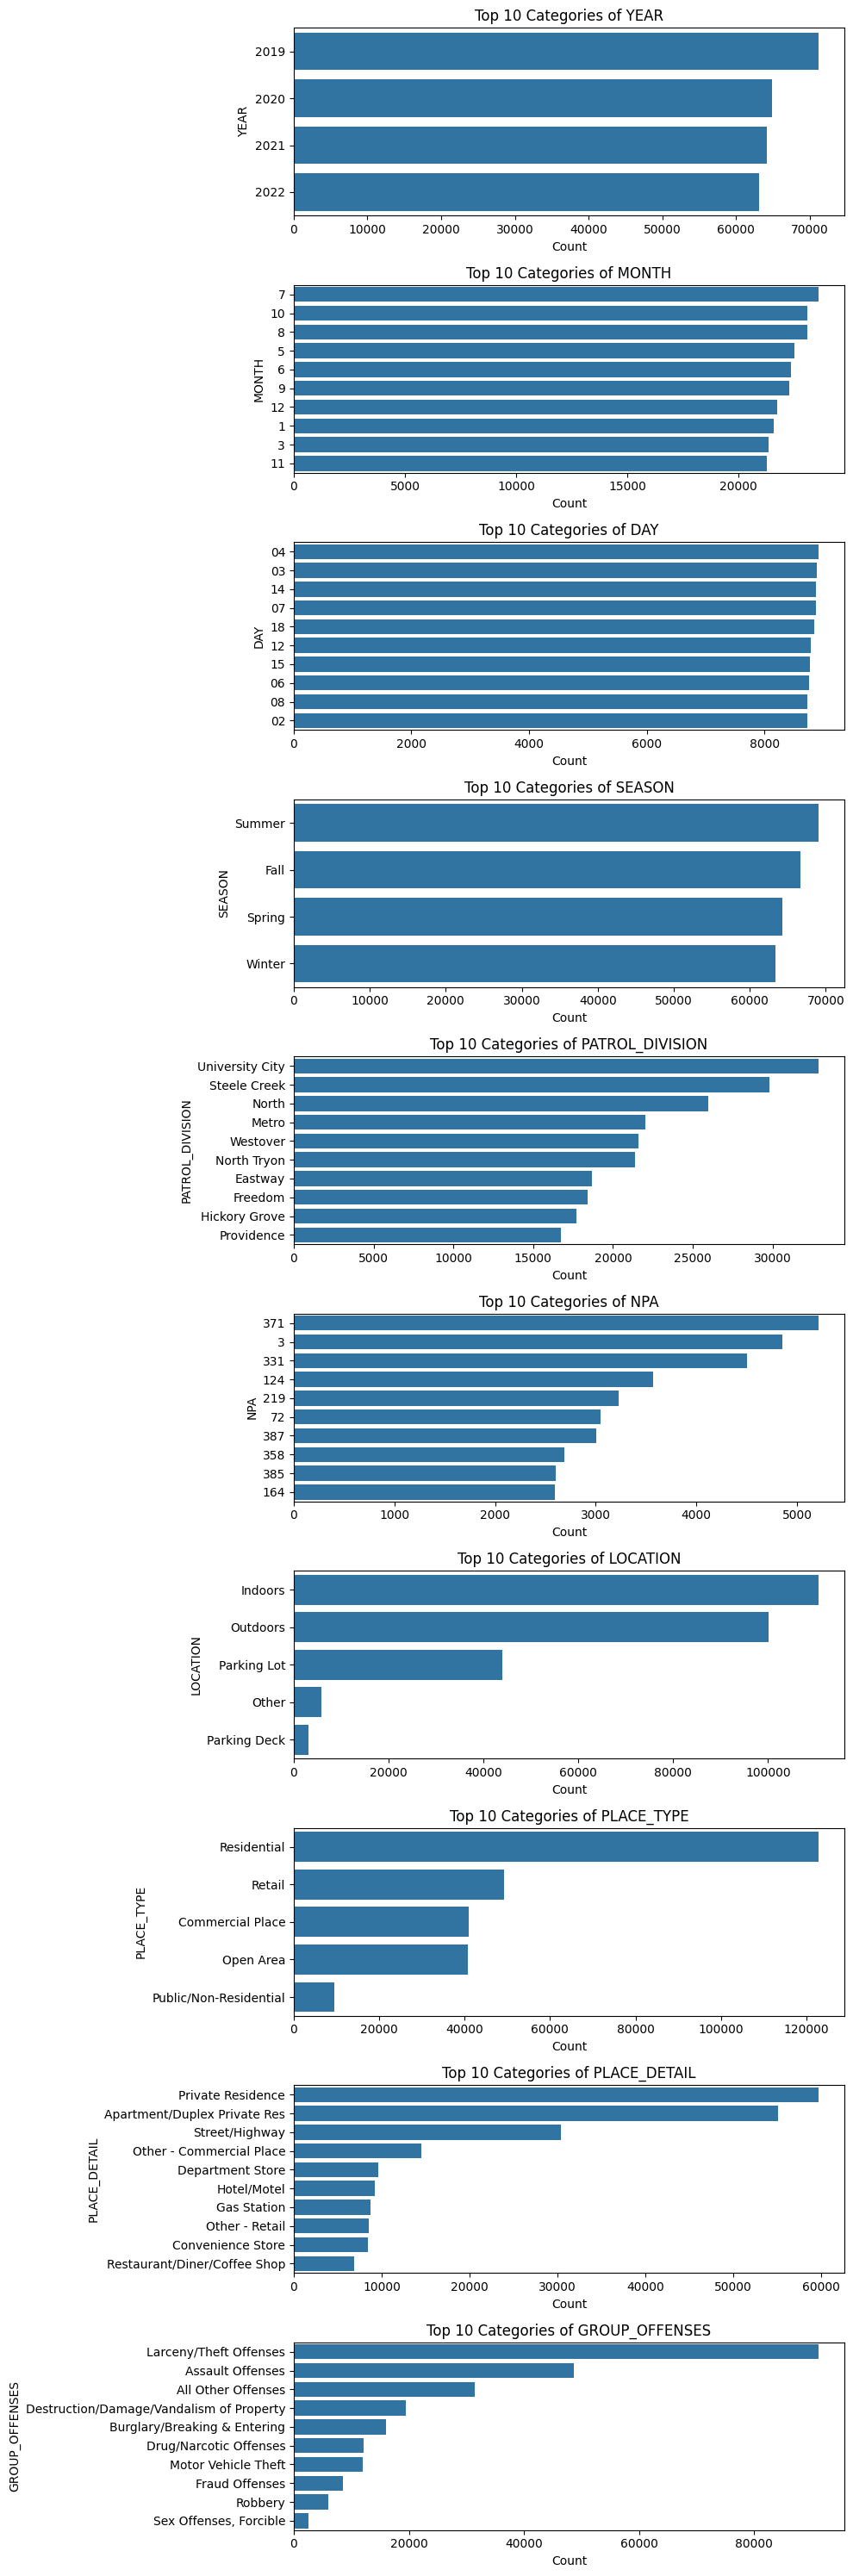

In [ ]:
categorical_features = ['YEAR', 'MONTH', 'DAY', 'SEASON', 'PATROL_DIVISION', 'NPA',
                       'LOCATION', 'PLACE_TYPE', 'PLACE_DETAIL', 'GROUP_OFFENSES']

sorted_columns = sorted(categorical_features, key=lambda x: df_merged[x].value_counts().sum(), reverse=True)

num_columns = 1
num_rows = -(-len(sorted_columns) // num_columns)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_columns, figsize=(10, 3*num_rows))

axes = axes.flatten()

for i, (column, ax) in enumerate(zip(sorted_columns, axes)):
    top_10_categories = df_merged[column].value_counts().head(10)
    sns.countplot(y=column, data=df_merged[df_merged[column].isin(top_10_categories.index)], ax=ax, order=top_10_categories.index)
    ax.set_title(f'Top 10 Categories of {column}')
    ax.set_xlabel('Count')
    ax.set_ylabel(column)
    ax.tick_params(axis='y', rotation=0)

for ax in axes[len(sorted_columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

##Variable Assignment

#####X & Y

In [ ]:
X = df_merged.drop(columns='MONTHLY_CRIME_COUNT')
y = df_merged['MONTHLY_CRIME_COUNT']

##Addressing Skewness

#####Before Transformation

In [ ]:
df_merged[numerical_features].skew(skipna=True)

,0
UNRATE,2.168948
TOTAL_POPULATION,2.234538
PEOPLE_PER_ACRE,1.884852
MEDIAN_AGE_OF_RESIDENT,0.867287
MEDIAN_HOUSEHOLD_INCOME,1.725530


#####Transformation

In [ ]:
epsilon = 1e-8

variables_to_transform = ["UNRATE", "TOTAL_POPULATION", "PEOPLE_PER_ACRE", "MEDIAN_HOUSEHOLD_INCOME"]

df_merged[variables_to_transform] = df_merged[variables_to_transform].apply(lambda x: np.log(x + epsilon) if x.min() > 0 else np.log(x + 1))

#####After Transformation

In [ ]:
df_merged[numerical_features].skew(skipna=True)

,0
UNRATE,1.373626
TOTAL_POPULATION,0.123349
PEOPLE_PER_ACRE,-0.462563
MEDIAN_AGE_OF_RESIDENT,0.867287
MEDIAN_HOUSEHOLD_INCOME,0.226570


##Addressing Multicollinearity

#####Initial VIF Scores

In [ ]:
vif_data = pd.DataFrame()
vif_data['feature'] = X[numerical_features].columns
vif_data['VIF'] = [variance_inflation_factor(X[numerical_features].values,i)
                  for i in range (len(X[numerical_features].columns))]
vif_data

,feature,VIF
0,UNRATE,4.847835
1,TOTAL_POPULATION,3.703121
2,PEOPLE_PER_ACRE,3.186258
3,MEDIAN_AGE_OF_RESIDENT,8.739377
4,MEDIAN_HOUSEHOLD_INCOME,5.241149


## Data Preprocessing

#####Split into train/test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#####Transform using Pipeline

In [ ]:
continuous_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ])

##Models

###Linear Regression

In [ ]:
LR_model = LinearRegression()

LR_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('LinearRegression', LR_model)
])

LR_pipeline.fit(X_train, y_train)

n = len(y_train)
p = X_train.shape[1]
R2 = LR_pipeline.score(X_train, y_train)
adjusted_R2 = 1 - (1 - R2) * (n - 1) / (n - p - 1)

y_pred = LR_pipeline.predict(X_test)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Adjusted R^2:", adjusted_R2)
print("MAPE:", mape)

Adjusted R^2: 0.9039848177916424
MAPE: 1.8933085808415646


In [ ]:
categorical_feature_names = LR_pipeline.named_steps['preprocessor']\
                                 .transformers_[0][1]\
                                 .get_feature_names_out(categorical_features)

feature_names = np.concatenate([categorical_feature_names, numerical_features])

coefficients = LR_pipeline.named_steps['LinearRegression'].coef_

feature_importance = pd.Series(coefficients, index=feature_names)

feature_importance = feature_importance.abs().nlargest(10)

print("Top 10 Feature Importance:")
print(feature_importance)

Top 10 Feature Importance:
YEAR_2022        384.840548
MONTH_2          344.770628
NPA_463          318.165894
MONTH_5          313.098199
YEAR_2019        289.207529
MONTH_11         252.065379
UNRATE           248.646232
MONTH_7          234.107416
SEASON_Summer    230.846466
MONTH_10         219.310295
dtype: float64


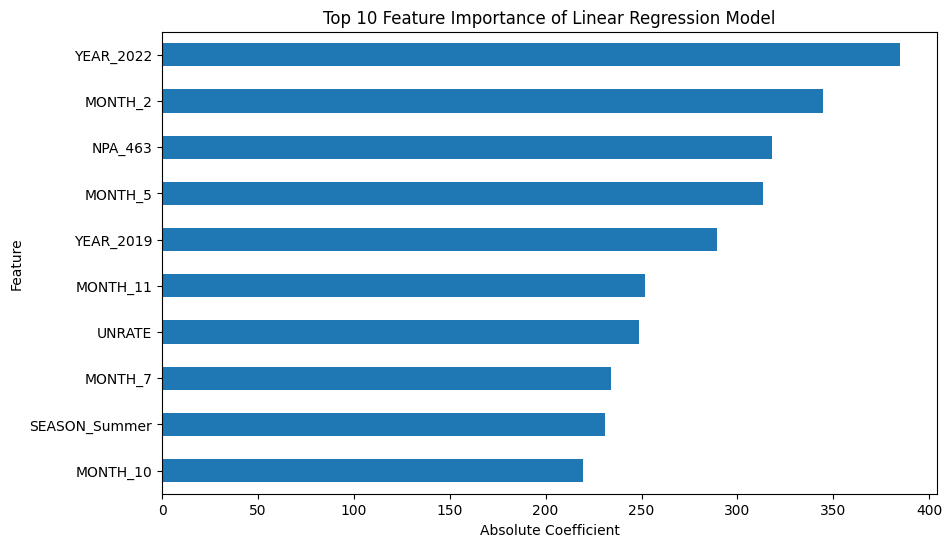

In [ ]:
features = feature_importance.index.tolist()
importances = feature_importance.values.tolist()

feature_importance_sorted = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance_sorted.plot(kind='barh')
plt.ylabel('Feature')
plt.xlabel('Absolute Coefficient')
plt.title('Top 10 Feature Importance of Linear Regression Model')
plt.show()

###Decision Tree Regressor

In [ ]:
# @title
DTR_model = DecisionTreeRegressor(random_state=42)

DTR_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('DecisionTreeRegressor', DTR_model)
])

DTR_pipeline.fit(X_train, y_train)

initial_predictions_train = DTR_pipeline.predict(X_train)
initial_predictions_test = DTR_pipeline.predict(X_test)
initial_r2_train = r2_score(y_train, initial_predictions_train)
initial_r2_test = r2_score(y_test, initial_predictions_test)
initial_mape_train = mean_absolute_percentage_error(y_train, initial_predictions_train)
initial_mape_test = mean_absolute_percentage_error(y_test, initial_predictions_test)

print("Initial R-squared on train set:", initial_r2_train)
print("Initial R-squared on test set:", initial_r2_test)
print("Initial MAPE on train set:", initial_mape_train)
print("Initial MAPE on test set:", initial_mape_test)

Initial R-squared on train set: 1.0
Initial R-squared on test set: 1.0
Initial MAPE on train set: 0.0
Initial MAPE on test set: 0.0


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

path = DTR_pipeline.named_steps['DecisionTreeRegressor'].cost_complexity_pruning_path(X_train_processed, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

X_train_small, X_val_small, y_train_small, y_val_small = train_test_split(X_train_processed, y_train, test_size=0.1, random_state=42)

best_score = float('-inf')
best_tree = None

for ccp_alpha in ccp_alphas:
    tree = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alpha, max_depth=4)
    tree.fit(X_train_small, y_train_small)

    val_score = tree.score(X_val_small, y_val_small)

    if val_score > best_score:
        best_score = val_score
        best_tree = tree

pruned_predictions_train = best_tree.predict(X_train_processed)
pruned_predictions_test = best_tree.predict(X_test_processed)
pruned_r2_train = r2_score(y_train, pruned_predictions_train)
pruned_r2_test = r2_score(y_test, pruned_predictions_test)
pruned_mape_train = mean_absolute_percentage_error(y_train, pruned_predictions_train)
pruned_mape_test = mean_absolute_percentage_error(y_test, pruned_predictions_test)

print("\nPruned R-squared on train set:", pruned_r2_train)
print("Pruned R-squared on test set:", pruned_r2_test)
print("Pruned MAPE on train set:", pruned_mape_train)
print("Pruned MAPE on test set:", pruned_mape_test)


Pruned R-squared on train set: 0.7527258241845275
Pruned R-squared on test set: 0.7535739917134507
Pruned MAPE on train set: 0.028149426696277426
Pruned MAPE on test set: 0.028015432836937068


In [ ]:
best_ccp_alpha = best_tree.ccp_alpha
final_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=best_ccp_alpha)
final_tree.fit(X_train_processed, y_train)

feature_importances = final_tree.feature_importances_

feature_importance_list = list(zip(X_train.columns, feature_importances))

feature_importance_list.sort(key=lambda x: x[1], reverse=True)

print("Feature importances:")
for feature, importance in feature_importance_list:
    print(f"{feature}: {importance}")

Feature importances:
YEAR: 0.38851888088044045
PLACE_DETAIL: 0.07651073422823536
MONTH: 0.04933359465660693
GROUP: 0.040096309711576995
OFFENSE_CODE: 0.03618357184903517
NPA: 0.02714439723664899
DAY: 0.025732477474293684
PATROL_DIVISION: 0.022968901446906345
LOCATION: 0.02145649971033403
TOTAL_POPULATION: 0.00477866906647088
PEOPLE_PER_ACRE: 0.003972979870361911
GROUP_OFFENSES: 0.0035273172586450774
CRIME_AGAINST: 0.003313106661110788
UNRATE: 0.002217658394613576
SEASON: 0.0017208277182767355
PLACE_TYPE: 0.0005528856885677165
MEDIAN_AGE_OF_RESIDENT: 0.0
MEDIAN_HOUSEHOLD_INCOME: 0.0


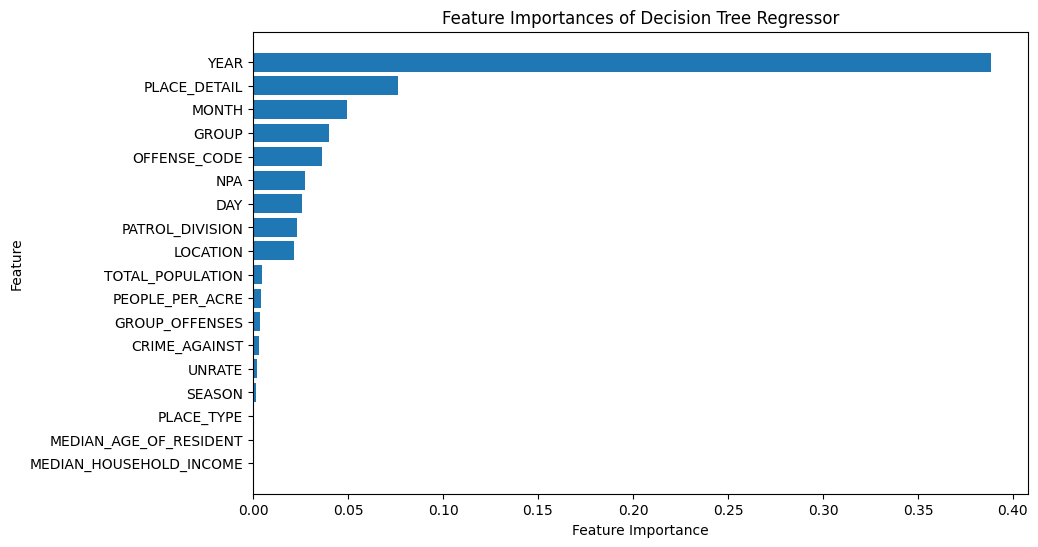

In [ ]:
features = [x[0] for x in feature_importance_list]
importances = [x[1] for x in feature_importance_list]

plt.figure(figsize=(10, 6))
plt.barh(features, importances, align='center')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances of Decision Tree Regressor')
plt.gca().invert_yaxis()
plt.show()

###XGBoost Regressor

In [ ]:
models = {
    "XGBoost": xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
}
adjusted_r2_results = []
mape_results = []

for model_name, model in models.items():
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    kf = KFold(n_splits=6, random_state=42, shuffle=True)
    model_pipeline.fit(X_train, y_train)
    y_pred = cross_val_predict(model_pipeline, X_train, y_train, cv=kf)
    n = len(y_train)
    p = X_train.shape[1]
    r2 = model_pipeline.named_steps['model'].score(model_pipeline.named_steps['preprocessor'].transform(X_train), y_train)
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    adjusted_r2_results.append((model_name, adjusted_r2))
    mape = np.mean(np.abs((y_train - y_pred) / y_train)) * 100
    mape_results.append((model_name, mape))

print("Adjusted R^2:")
for model_name, adjusted_r2 in adjusted_r2_results:
    print(f"{model_name}: {adjusted_r2}")

print("\nMAPE:")
for model_name, mape in mape_results:
    print(f"{model_name}: {mape}")

Adjusted R^2:
XGBoost: 0.999999999996171

MAPE:
XGBoost: 8.434351956465126e-06


In [ ]:
test_r2_results = []
test_mape_results = []

for model_name, model in models.items():
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    model_pipeline.fit(X_train, y_train)
    y_test_pred = model_pipeline.predict(X_test)
    test_r2 = r2_score(y_test, y_test_pred)
    test_r2_results.append((model_name, test_r2))
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
    test_mape_results.append((model_name, test_mape))

print("Test R^2:")
for model_name, test_r2 in test_r2_results:
    print(f"{model_name}: {test_r2}")

print("\nTest MAPE:")
for model_name, test_mape in test_mape_results:
    print(f"{model_name}: {test_mape}")

Test R^2:
XGBoost: 0.9999999999961561

Test MAPE:
XGBoost: 1.170801205992762e-05


In [ ]:
final_model = models["XGBoost"]
final_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])
final_model_pipeline.fit(X_train, y_train)

feature_importances = final_model.feature_importances_

numeric_features = X_train.columns

feature_importance_dict = dict(zip(numeric_features, feature_importances))

sorted_feature_importances = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

print("\nFeature Importances:")
for feature, importance in sorted_feature_importances:
    print(f"{feature}: {importance}")


Feature Importances:
YEAR: 0.11867054551839828
PLACE_DETAIL: 0.09208090603351593
OFFENSE_CODE: 0.05222602188587189
GROUP: 0.04436124116182327
NPA: 0.033563874661922455
DAY: 0.027023715898394585
MONTH: 0.026209905743598938
LOCATION: 0.024582725018262863
SEASON: 0.017404664307832718
PATROL_DIVISION: 0.01552741788327694
GROUP_OFFENSES: 0.015329448506236076
CRIME_AGAINST: 0.008434727787971497
PLACE_TYPE: 0.006717074662446976
TOTAL_POPULATION: 0.005422614049166441
PEOPLE_PER_ACRE: 0.0023159547708928585
UNRATE: 0.0010001701302826405
MEDIAN_AGE_OF_RESIDENT: 0.0
MEDIAN_HOUSEHOLD_INCOME: 0.0


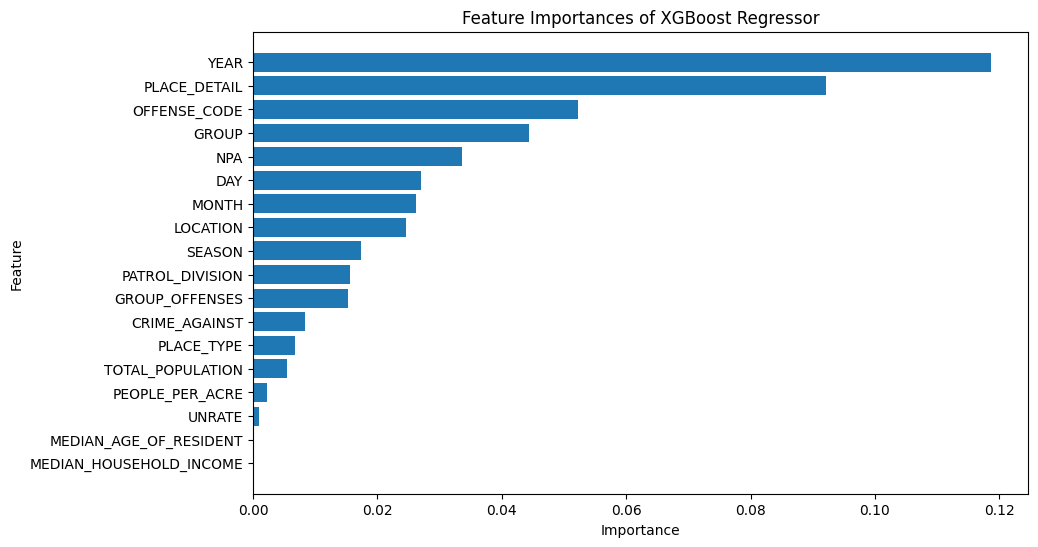

In [ ]:
features = [x[0] for x in sorted_feature_importances]
importances = [x[1] for x in sorted_feature_importances]

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances of XGBoost Regressor')
plt.gca().invert_yaxis()
plt.show()

###Time-Series Forecasting

####Monthly Time Series Forecasting (Univariate)

##### Monthly Time Series Preprocessing

In [ ]:
df_CMPD_cleaned.head()

,YEAR,CMPD_PATROL_DIVISION,NPA,DATE_REPORTED,LOCATION_TYPE_DESCRIPTION,PLACE_TYPE_DESCRIPTION,PLACE_DETAIL_DESCRIPTION,HIGHEST_NIBRS_CODE,MONTH,DAY,SEASON
2,2024,University City,192,2024-02-22 00:00:00+00:00,Outdoors,Residential,Private Residence,23H,2,22,Winter
3,2024,Providence,3,2024-02-22 00:00:00+00:00,Parking Deck,Public/Non-Residential,Hospital/Medical Facility,290,2,22,Winter
6,2024,Westover,121,2024-02-22 00:00:00+00:00,Outdoors,Open Area,Other - Open Area,23H,2,22,Winter
7,2024,Eastway,164,2024-02-22 00:00:00+00:00,Outdoors,Open Area,Street/Highway,35A,2,22,Winter
8,2024,South,25,2024-02-22 00:00:00+00:00,Indoors,Retail,Other - Retail,23C,2,22,Winter


In [ ]:
df_CMPD_cleaned['DATE_REPORTED'] = pd.to_datetime(df_CMPD_cleaned['DATE_REPORTED'])


In [ ]:
MONTHLY_CRIME_COUNT = df_CMPD_cleaned.groupby([df_CMPD_cleaned['DATE_REPORTED'].dt.year, df_CMPD_cleaned['DATE_REPORTED'].dt.month]).size().rename('MONTHLY_CRIME_COUNT')
df_CMPD_ts = df_CMPD_cleaned.merge(MONTHLY_CRIME_COUNT, how='left', left_on=[df_CMPD_cleaned['DATE_REPORTED'].dt.year, df_CMPD_cleaned['DATE_REPORTED'].dt.month], right_index=True, suffixes=('', '_count'))
df_CMPD_ts.reset_index(drop=True, inplace=True)
df_CMPD_ts.head()

,YEAR,CMPD_PATROL_DIVISION,NPA,DATE_REPORTED,LOCATION_TYPE_DESCRIPTION,PLACE_TYPE_DESCRIPTION,PLACE_DETAIL_DESCRIPTION,HIGHEST_NIBRS_CODE,MONTH,DAY,SEASON,MONTHLY_CRIME_COUNT
0,2024,University City,192,2024-02-22 00:00:00+00:00,Outdoors,Residential,Private Residence,23H,2,22,Winter,4508
1,2024,Providence,3,2024-02-22 00:00:00+00:00,Parking Deck,Public/Non-Residential,Hospital/Medical Facility,290,2,22,Winter,4508
2,2024,Westover,121,2024-02-22 00:00:00+00:00,Outdoors,Open Area,Other - Open Area,23H,2,22,Winter,4508
3,2024,Eastway,164,2024-02-22 00:00:00+00:00,Outdoors,Open Area,Street/Highway,35A,2,22,Winter,4508
4,2024,South,25,2024-02-22 00:00:00+00:00,Indoors,Retail,Other - Retail,23C,2,22,Winter,4508


In [ ]:
# Calculate daily crime counts
df_CMPD_ts['DATE_REPORTED'] = pd.to_datetime(df_CMPD_ts['DATE_REPORTED'])
DAILY_CRIME_COUNT = df_CMPD_ts.groupby(df_CMPD_ts['DATE_REPORTED'].dt.date).size().rename('DAILY_CRIME_COUNT')

# Merge the daily counts back into the original DataFrame
# Note: Ensure DATE_REPORTED is cast to date format for matching
df_CMPD_ts['DATE_REPORTED_DATE'] = df_CMPD_ts['DATE_REPORTED'].dt.date
df_CMPD_ts= df_CMPD_ts.merge(DAILY_CRIME_COUNT, how='left', left_on='DATE_REPORTED_DATE', right_index=True)

# Drop the additional DATE_REPORTED_DATE column if it's no longer needed
df_CMPD_ts.drop('DATE_REPORTED_DATE', axis=1, inplace=True)

# Reset the index of the DataFrame if necessary
df_CMPD_ts.reset_index(drop=True, inplace=True)

In [ ]:
df_CMPD_ts.head()

,YEAR,CMPD_PATROL_DIVISION,NPA,DATE_REPORTED,LOCATION_TYPE_DESCRIPTION,PLACE_TYPE_DESCRIPTION,PLACE_DETAIL_DESCRIPTION,HIGHEST_NIBRS_CODE,MONTH,DAY,SEASON,MONTHLY_CRIME_COUNT,DAILY_CRIME_COUNT
0,2024,University City,192,2024-02-22 00:00:00+00:00,Outdoors,Residential,Private Residence,23H,2,22,Winter,4508,143
1,2024,Providence,3,2024-02-22 00:00:00+00:00,Parking Deck,Public/Non-Residential,Hospital/Medical Facility,290,2,22,Winter,4508,143
2,2024,Westover,121,2024-02-22 00:00:00+00:00,Outdoors,Open Area,Other - Open Area,23H,2,22,Winter,4508,143
3,2024,Eastway,164,2024-02-22 00:00:00+00:00,Outdoors,Open Area,Street/Highway,35A,2,22,Winter,4508,143
4,2024,South,25,2024-02-22 00:00:00+00:00,Indoors,Retail,Other - Retail,23C,2,22,Winter,4508,143


In [ ]:
df_CMPD_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530489 entries, 0 to 530488
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   YEAR                       530489 non-null  int64              
 1   CMPD_PATROL_DIVISION       530489 non-null  object             
 2   NPA                        530489 non-null  int64              
 3   DATE_REPORTED              530489 non-null  datetime64[ns, UTC]
 4   LOCATION_TYPE_DESCRIPTION  530489 non-null  object             
 5   PLACE_TYPE_DESCRIPTION     530489 non-null  object             
 6   PLACE_DETAIL_DESCRIPTION   530489 non-null  object             
 7   HIGHEST_NIBRS_CODE         530489 non-null  object             
 8   MONTH                      530489 non-null  int64              
 9   DAY                        530489 non-null  object             
 10  SEASON                     530489 non-null  object      

In [ ]:

df_CMPD_ts['DATE_REPORTED'] = df_CMPD_ts['DATE_REPORTED'].dt.date


In [ ]:
df_CMPD_ts.head()

,YEAR,CMPD_PATROL_DIVISION,NPA,DATE_REPORTED,LOCATION_TYPE_DESCRIPTION,PLACE_TYPE_DESCRIPTION,PLACE_DETAIL_DESCRIPTION,HIGHEST_NIBRS_CODE,MONTH,DAY,SEASON,MONTHLY_CRIME_COUNT,DAILY_CRIME_COUNT
0,2024,University City,192,2024-02-22,Outdoors,Residential,Private Residence,23H,2,22,Winter,4508,143
1,2024,Providence,3,2024-02-22,Parking Deck,Public/Non-Residential,Hospital/Medical Facility,290,2,22,Winter,4508,143
2,2024,Westover,121,2024-02-22,Outdoors,Open Area,Other - Open Area,23H,2,22,Winter,4508,143
3,2024,Eastway,164,2024-02-22,Outdoors,Open Area,Street/Highway,35A,2,22,Winter,4508,143
4,2024,South,25,2024-02-22,Indoors,Retail,Other - Retail,23C,2,22,Winter,4508,143


In [ ]:
df_CMPD_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530489 entries, 0 to 530488
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   YEAR                       530489 non-null  int64 
 1   CMPD_PATROL_DIVISION       530489 non-null  object
 2   NPA                        530489 non-null  int64 
 3   DATE_REPORTED              530489 non-null  object
 4   LOCATION_TYPE_DESCRIPTION  530489 non-null  object
 5   PLACE_TYPE_DESCRIPTION     530489 non-null  object
 6   PLACE_DETAIL_DESCRIPTION   530489 non-null  object
 7   HIGHEST_NIBRS_CODE         530489 non-null  object
 8   MONTH                      530489 non-null  int64 
 9   DAY                        530489 non-null  object
 10  SEASON                     530489 non-null  object
 11  MONTHLY_CRIME_COUNT        530489 non-null  int64 
 12  DAILY_CRIME_COUNT          530489 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 52.6+ M

In [ ]:
# Convert 'DATE_REPORTED' back to datetime to set as index
df_CMPD_ts['DATE_REPORTED'] = pd.to_datetime(df_CMPD_ts['DATE_REPORTED'])



In [ ]:
df_CMPD_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530489 entries, 0 to 530488
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   YEAR                       530489 non-null  int64         
 1   CMPD_PATROL_DIVISION       530489 non-null  object        
 2   NPA                        530489 non-null  int64         
 3   DATE_REPORTED              530489 non-null  datetime64[ns]
 4   LOCATION_TYPE_DESCRIPTION  530489 non-null  object        
 5   PLACE_TYPE_DESCRIPTION     530489 non-null  object        
 6   PLACE_DETAIL_DESCRIPTION   530489 non-null  object        
 7   HIGHEST_NIBRS_CODE         530489 non-null  object        
 8   MONTH                      530489 non-null  int64         
 9   DAY                        530489 non-null  object        
 10  SEASON                     530489 non-null  object        
 11  MONTHLY_CRIME_COUNT        530489 non-null  int64   

In [ ]:
df_CMPD_ts.set_index('DATE_REPORTED', inplace=True)

In [ ]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
# MONTHLY_CRIME_COUNT' is the same for each day of a given month, take the first one
monthly_ts = df_CMPD_ts['MONTHLY_CRIME_COUNT'].resample('M').first()

monthly_ts.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 86 entries, 2017-01-31 to 2024-02-29
Freq: M
Series name: MONTHLY_CRIME_COUNT
Non-Null Count  Dtype
--------------  -----
86 non-null     int64
dtypes: int64(1)
memory usage: 1.3 KB


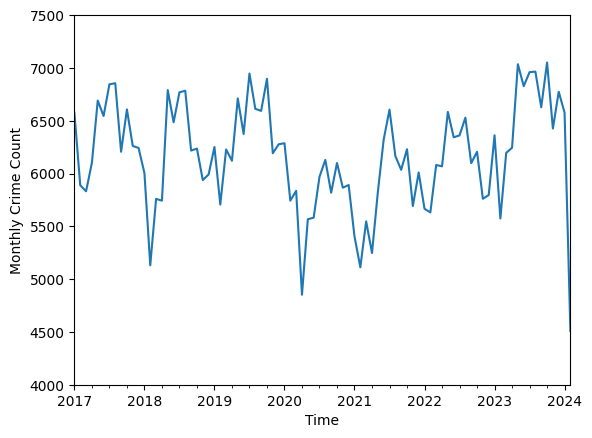

In [ ]:
ax = monthly_ts.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Monthly Crime Count')
ax.set_ylim(4000,7500)
plt.show()

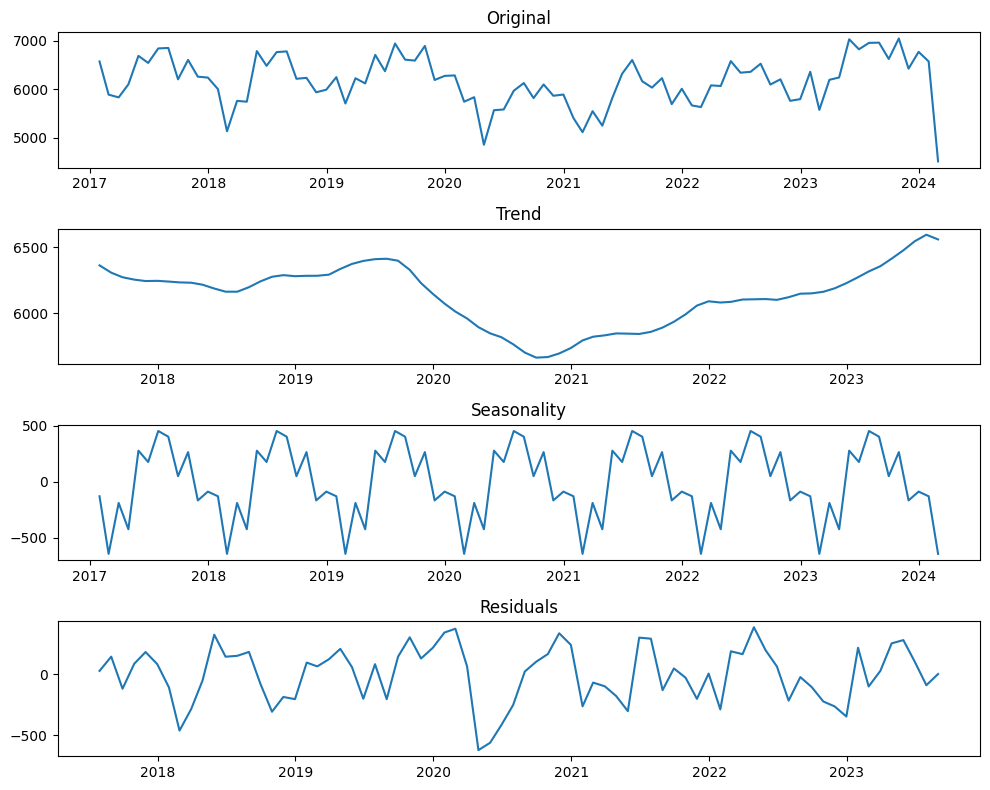

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Decomposing the time series to check for seasonality, trend, and residuals
decomposition = seasonal_decompose(monthly_ts, model='additive', period =12)

# Plotting the decomposed components
fig, ax = plt.subplots(4, 1, figsize=(10, 8))
ax[0].plot(decomposition.observed)
ax[0].set_title('Original')
ax[1].plot(decomposition.trend)
ax[1].set_title('Trend')
ax[2].plot(decomposition.seasonal)
ax[2].set_title('Seasonality')
ax[3].plot(decomposition.resid)
ax[3].set_title('Residuals')
plt.tight_layout()
plt.show()

In [ ]:
# separate into training and validation
nValid_month = 24
nTrain_month = len(monthly_ts)-nValid_month

trainmonth_ts =monthly_ts[:nTrain_month]
validmonth_ts = monthly_ts[nTrain_month:]

In [ ]:
trainmonth_ts

,MONTHLY_CRIME_COUNT
DATE_REPORTED,
2017-01-31,6575
2017-02-28,5889
2017-03-31,5832
2017-04-30,6102
2017-05-31,6691
2017-06-30,6545
2017-07-31,6845
2017-08-31,6855
2017-09-30,6206


In [ ]:
validmonth_ts

,MONTHLY_CRIME_COUNT
DATE_REPORTED,
2022-03-31,6081
2022-04-30,6068
2022-05-31,6583
2022-06-30,6343
2022-07-31,6361
2022-08-31,6529
2022-09-30,6098
2022-10-31,6206
2022-11-30,5761


In [ ]:
import statsmodels.formula.api as sm
from statsmodels.tsa import tsatools, stattools

ts_df = tsatools.add_trend(monthly_ts, trend='t')
ts_df['Month'] = ts_df.index.month

ts_df

,MONTHLY_CRIME_COUNT,trend,Month
DATE_REPORTED,,,
2017-01-31,6575,1.0,1
2017-02-28,5889,2.0,2
2017-03-31,5832,3.0,3
2017-04-30,6102,4.0,4
2017-05-31,6691,5.0,5
2017-06-30,6545,6.0,6
2017-07-31,6845,7.0,7
2017-08-31,6855,8.0,8
2017-09-30,6206,9.0,9


In [ ]:
len(monthly_ts)

86

##### Linear Trend

In [ ]:
# linear trend

trainmonth_df = ts_df[:nTrain_month]
validmonth_df = ts_df[nTrain_month:]

monthly_lm = sm.ols(formula='MONTHLY_CRIME_COUNT~trend',data=trainmonth_df).fit()

monthly_lm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     MONTHLY_CRIME_COUNT   R-squared:                       0.154
Model:                             OLS   Adj. R-squared:                  0.140
Method:                  Least Squares   F-statistic:                     10.89
Date:                 Sat, 03 Aug 2024   Prob (F-statistic):            0.00163
Time:                         23:34:14   Log-Likelihood:                -464.26
No. Observations:                   62   AIC:                             932.5
Df Residuals:                       60   BIC:                             936.8
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6429.6420    112.984     56.907      0.000    6203.640    6655.644
trend        -10.2918      3.119     -3.300      0.002     -16.530      -4.054
==============================================================================
Omnibus:                        2.273   Durbin-Watson:                   0.945
Prob(Omnibus):                  0.321   Jarque-Bera (JB):                1.729
Skew:                          -0.405   Prob(JB):                        0.421
Kurtosis:                       3.116   Cond. No.                         73.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
from dmba import regressionSummary
# predict using linear time series model
predict_lm_month = monthly_lm.predict(validmonth_df)
lm_metrics =regressionSummary(validmonth_ts,predict_lm_month)

Colab environment detected.

Regression statistics

                      Mean Error (ME) : 668.3856
       Root Mean Squared Error (RMSE) : 873.5450
            Mean Absolute Error (MAE) : 762.6025
          Mean Percentage Error (MPE) : 9.7631
Mean Absolute Percentage Error (MAPE) : 11.8199


#####**Quadratic Trends**

In [ ]:
monthly_lm_poly = sm.ols(formula='MONTHLY_CRIME_COUNT~trend+np.square(trend)',
                       data=trainmonth_df).fit()

monthly_lm_poly.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     MONTHLY_CRIME_COUNT   R-squared:                       0.158
Model:                             OLS   Adj. R-squared:                  0.129
Method:                  Least Squares   F-statistic:                     5.519
Date:                 Sat, 03 Aug 2024   Prob (F-statistic):            0.00635
Time:                         23:34:14   Log-Likelihood:                -464.11
No. Observations:                   62   AIC:                             934.2
Df Residuals:                       59   BIC:                             940.6
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         6360.1290    174.030     36.546      0.000    6011.896    6708.362
trend               -3.7749     12.746     -0.296      0.768     -29.281      21.731
np.square(trend)    -0.1034      0.196     -0.527      0.600      -0.496       0.289
==============================================================================
Omnibus:                        2.704   Durbin-Watson:                   0.950
Prob(Omnibus):                  0.259   Jarque-Bera (JB):                2.089
Skew:                          -0.443   Prob(JB):                        0.352
Kurtosis:                       3.153   Cond. No.                     5.45e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.45e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
predictM_lm_poly = monthly_lm_poly.predict(validmonth_df)
regressionSummary(validmonth_ts,predictM_lm_poly)


Regression statistics

                      Mean Error (ME) : 831.4790
       Root Mean Squared Error (RMSE) : 1013.4968
            Mean Absolute Error (MAE) : 895.0149
          Mean Percentage Error (MPE) : 12.3627
Mean Absolute Percentage Error (MAPE) : 13.7721


##### Seasonality

In [ ]:
monthly_lm_season = sm.ols(formula='MONTHLY_CRIME_COUNT~C(Month)',data=trainmonth_df).fit()
monthly_lm_season.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     MONTHLY_CRIME_COUNT   R-squared:                       0.485
Model:                             OLS   Adj. R-squared:                  0.371
Method:                  Least Squares   F-statistic:                     4.274
Date:                 Sat, 03 Aug 2024   Prob (F-statistic):           0.000176
Time:                         23:34:14   Log-Likelihood:                -448.88
No. Observations:                   62   AIC:                             921.8
Df Residuals:                       50   BIC:                             947.3
Df Model:                           11                                         
Covariance Type:             nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       6031.1667    153.358     39.327      0.000    5723.138    6339.195
C(Month)[T.2]   -495.6667    216.881     -2.285      0.027    -931.284     -60.049
C(Month)[T.3]   -190.5667    227.466     -0.838      0.406    -647.446     266.313
C(Month)[T.4]   -418.1667    227.466     -1.838      0.072    -875.046      38.713
C(Month)[T.5]    285.2333    227.466      1.254      0.216    -171.646     742.113
C(Month)[T.6]    230.2333    227.466      1.012      0.316    -226.646     687.113
C(Month)[T.7]    595.8333    227.466      2.619      0.012     138.954    1052.713
C(Month)[T.8]    478.2333    227.466      2.102      0.041      21.354     935.113
C(Month)[T.9]    142.6333    227.466      0.627      0.533    -314.246     599.513
C(Month)[T.10]   382.8333    227.466      1.683      0.099     -74.046     839.713
C(Month)[T.11]   -41.3667    227.466     -0.182      0.856    -498.246     415.513
C(Month)[T.12]    51.0333    227.466      0.224      0.823    -405.846     507.913
==============================================================================
Omnibus:                        3.759   Durbin-Watson:                   0.513
Prob(Omnibus):                  0.153   Jarque-Bera (JB):                3.373
Skew:                          -0.488   Prob(JB):                        0.185
Kurtosis:                       2.406   Cond. No.                         12.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:

predictM_lm_season =monthly_lm_season.predict(validmonth_df)
regressionSummary(validmonth_ts,predictM_lm_season)


Regression statistics

                      Mean Error (ME) : 215.1028
       Root Mean Squared Error (RMSE) : 457.3351
            Mean Absolute Error (MAE) : 389.4611
          Mean Percentage Error (MPE) : 2.8886
Mean Absolute Percentage Error (MAPE) : 6.2618


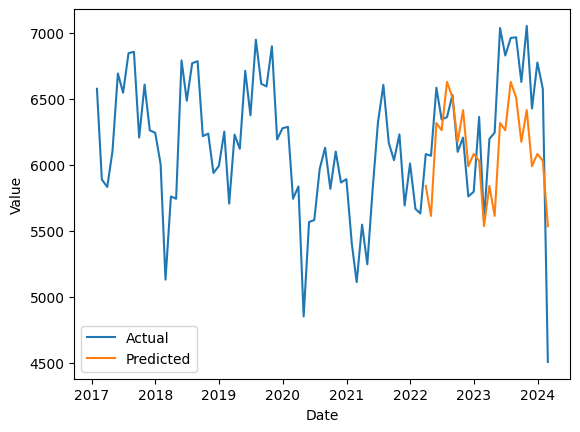

In [ ]:
# Plot the actual time series data
plt.plot(monthly_ts.index, monthly_ts, label='Actual')

# Plot the predicted time series data
plt.plot(predictM_lm_season.index, predictM_lm_season, label='Predicted')

# Add axis labels and a legend
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

# Show the plot
plt.show()


##### Linear Trend + Seasonality

Seasonality + Trends

In [ ]:
# used the better performing linear trend with seasonality
modelfomula_monthly = 'MONTHLY_CRIME_COUNT~trend+C(Month)'
monthly_lm_trendseason = sm.ols(formula=modelfomula_monthly,
                              data=trainmonth_df).fit()
monthly_lm_trendseason.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     MONTHLY_CRIME_COUNT   R-squared:                       0.659
Model:                             OLS   Adj. R-squared:                  0.575
Method:                  Least Squares   F-statistic:                     7.876
Date:                 Sat, 03 Aug 2024   Prob (F-statistic):           6.59e-08
Time:                         23:34:15   Log-Likelihood:                -436.12
No. Observations:                   62   AIC:                             898.2
Df Residuals:                       49   BIC:                             925.9
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       6374.2716    143.577     44.396      0.000    6085.743    6662.800
C(Month)[T.2]   -484.5988    178.332     -2.717      0.009    -842.970    -126.227
C(Month)[T.3]   -234.8383    187.231     -1.254      0.216    -611.094     141.417
C(Month)[T.4]   -451.3704    187.140     -2.412      0.020    -827.442     -75.299
C(Month)[T.5]    263.0975    187.074      1.406      0.166    -112.842     639.037
C(Month)[T.6]    219.1654    187.035      1.172      0.247    -156.695     595.026
C(Month)[T.7]    595.8333    187.022      3.186      0.003     219.999     971.667
C(Month)[T.8]    489.3012    187.035      2.616      0.012     113.441     865.162
C(Month)[T.9]    164.7691    187.074      0.881      0.383    -211.170     540.709
C(Month)[T.10]   416.0370    187.140      2.223      0.031      39.966     792.108
C(Month)[T.11]     2.9049    187.231      0.016      0.988    -373.351     379.161
C(Month)[T.12]   106.3728    187.349      0.568      0.573    -270.120     482.865
trend            -11.0679      2.215     -4.996      0.000     -15.519      -6.616
==============================================================================
Omnibus:                        1.793   Durbin-Watson:                   0.771
Prob(Omnibus):                  0.408   Jarque-Bera (JB):                1.719
Skew:                          -0.389   Prob(JB):                        0.423
Kurtosis:                       2.752   Cond. No.                         422.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
predictM_lm_trendseason = monthly_lm_trendseason.predict(validmonth_df)
regressionSummary(validmonth_ts, predictM_lm_trendseason)


Regression statistics

                      Mean Error (ME) : 691.0225
       Root Mean Squared Error (RMSE) : 815.1877
            Mean Absolute Error (MAE) : 726.8420
          Mean Percentage Error (MPE) : 10.4675
Mean Absolute Percentage Error (MAPE) : 11.2621


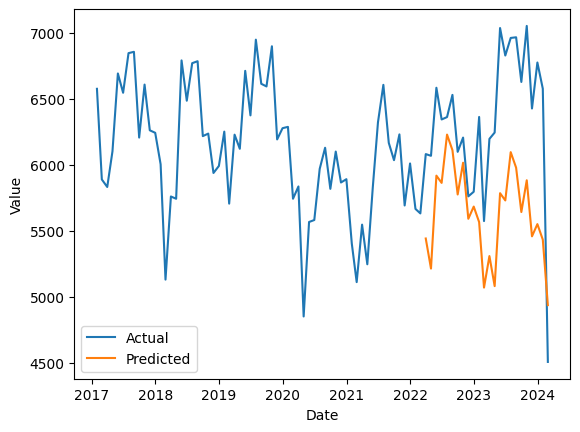

In [ ]:
import matplotlib.pyplot as plt

# Plot the actual time series data
plt.plot(monthly_ts.index, monthly_ts, label='Actual')

# Plot the predicted time series data
plt.plot(predictM_lm_trendseason.index, predictM_lm_trendseason, label='Predicted')

# Add axis labels and a legend
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

# Show the plot
plt.show()


##### Simple Moving Average

In [ ]:
ma_month = trainmonth_ts.rolling(12).mean()
ma_month

,MONTHLY_CRIME_COUNT
DATE_REPORTED,
2017-01-31,NaN
2017-02-28,NaN
2017-03-31,NaN
2017-04-30,NaN
2017-05-31,NaN
2017-06-30,NaN
2017-07-31,NaN
2017-08-31,NaN
2017-09-30,NaN


In [ ]:
last_ma_month = ma_month[-1]

predictM_ma = pd.Series(last_ma_month,index=validmonth_ts.index)
combineM_ma = pd.concat([ma_month, predictM_ma])

print(ma_month)

DATE_REPORTED
2017-01-31            NaN
2017-02-28            NaN
2017-03-31            NaN
2017-04-30            NaN
2017-05-31            NaN
2017-06-30            NaN
2017-07-31            NaN
2017-08-31            NaN
2017-09-30            NaN
2017-10-31            NaN
2017-11-30            NaN
2017-12-31    6387.500000
2018-01-31    6339.916667
2018-02-28    6276.750000
2018-03-31    6270.750000
2018-04-30    6240.833333
2018-05-31    6249.083333
2018-06-30    6244.083333
2018-07-31    6237.750000
2018-08-31    6231.833333
2018-09-30    6232.750000
2018-10-31    6201.833333
2018-11-30    6174.916667
2018-12-31    6154.000000
2019-01-31    6174.583333
2019-02-28    6222.500000
2019-03-31    6261.500000
2019-04-30    6293.000000
2019-05-31    6286.416667
2019-06-30    6277.166667
2019-07-31    6292.000000
2019-08-31    6277.750000
2019-09-30    6309.083333
2019-10-31    6364.166667
2019-11-30    6385.333333
2019-12-31    6409.166667
2020-01-31    6412.166667
2020-02-29    6415.25000

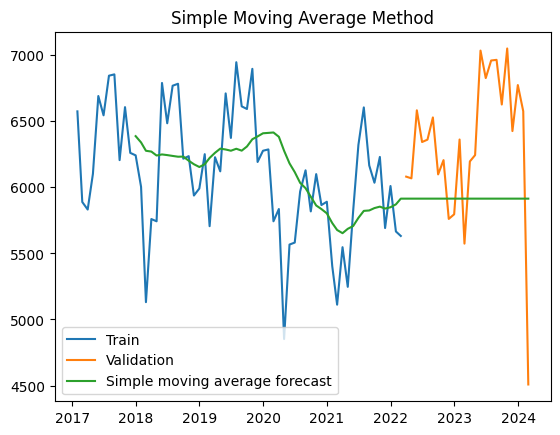

In [ ]:
# plot moving average
plt.plot(trainmonth_ts, label='Train')
plt.plot(validmonth_ts, label='Validation')
plt.plot(combineM_ma, label='Simple moving average forecast')
plt.legend(loc='best')
plt.title('Simple Moving Average Method')
plt.show()

In [ ]:
regressionSummary(validmonth_ts,predictM_ma)


Regression statistics

                      Mean Error (ME) : 416.7917
       Root Mean Squared Error (RMSE) : 689.7857
            Mean Absolute Error (MAE) : 585.0417
          Mean Percentage Error (MPE) : 5.7553
Mean Absolute Percentage Error (MAPE) : 9.2568


In [ ]:
from statsmodels.tsa.api import SimpleExpSmoothing
SES = SimpleExpSmoothing(trainmonth_ts,
                         initialization_method='estimated').fit() # estimated method is used, which estimates the initial smoothing level based on the data; which finds the value of alpha that minimizes the sum of squared errors between the predicted and actual values
predictM_SES = SES.forecast(len(validmonth_ts))

SES.model.params

regressionSummary(validmonth_ts, predictM_SES)

combineM_SES = pd.concat([SES.fittedvalues, predictM_SES])


Regression statistics

                      Mean Error (ME) : 662.3623
       Root Mean Squared Error (RMSE) : 860.7048
            Mean Absolute Error (MAE) : 767.0172
          Mean Percentage Error (MPE) : 9.6683
Mean Absolute Percentage Error (MAPE) : 11.9563


##### Prophet

In [ ]:
from prophet import Prophet

df_prophet_month = pd.DataFrame({'ds': trainmonth_ts.index, 'y': trainmonth_ts.values})
df_prophet_month

,ds,y
0,2017-01-31,6575
1,2017-02-28,5889
2,2017-03-31,5832
3,2017-04-30,6102
4,2017-05-31,6691
5,2017-06-30,6545
6,2017-07-31,6845
7,2017-08-31,6855
8,2017-09-30,6206
9,2017-10-31,6607


In [ ]:
# Initialize the Prophet model
model_prophet_month = Prophet(changepoint_prior_scale=0.5)

# Fit the model with your DataFrame
model_prophet_month.fit(df_prophet_month)

# Create a DataFrame with future dates for prediction; replace 'periods' with the number of periods you're predicting
future24 = model_prophet_month.make_future_dataframe(periods=24, freq='M')
future24

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsfk5y5lw/8wu9mraw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsfk5y5lw/07hnfg2n.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=12238', 'data', 'file=/tmp/tmpsfk5y5lw/8wu9mraw.json', 'init=/tmp/tmpsfk5y5lw/07hnfg2n.json', 'output', 'file=/tmp/tmpsfk5y5lw/prophet_modelk2kg6z3q/prophet_model-20240803233416.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:34:16 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:34:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


,ds
0,2017-01-31
1,2017-02-28
2,2017-03-31
3,2017-04-30
4,2017-05-31
5,2017-06-30
6,2017-07-31
7,2017-08-31
8,2017-09-30
9,2017-10-31


In [ ]:
# Use the model to make predictions
prophet_predict = model_prophet_month.predict(future24)
prophet_predict


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-31,6637.754295,6103.896437,6488.350775,6637.754295,6637.754295,-342.250434,-342.250434,-342.250434,-342.250434,-342.250434,-342.250434,0.0,0.0,0.0,6295.503861
1,2017-02-28,6606.569834,5787.737593,6171.714769,6606.569834,6606.569834,-624.661973,-624.661973,-624.661973,-624.661973,-624.661973,-624.661973,0.0,0.0,0.0,5981.907861
2,2017-03-31,6572.044181,6024.101045,6395.589523,6572.044181,6572.044181,-355.866400,-355.866400,-355.866400,-355.866400,-355.866400,-355.866400,0.0,0.0,0.0,6216.177780
3,2017-04-30,6538.687157,5728.939858,6124.200017,6538.687157,6538.687157,-623.521625,-623.521625,-623.521625,-623.521625,-623.521625,-623.521625,0.0,0.0,0.0,5915.165532
4,2017-05-31,6504.218233,6425.948317,6833.759848,6504.218233,6504.218233,126.513112,126.513112,126.513112,126.513112,126.513112,126.513112,0.0,0.0,0.0,6630.731346
5,2017-06-30,6470.861210,6390.704998,6784.972567,6470.861210,6470.861210,122.650223,122.650223,122.650223,122.650223,122.650223,122.650223,0.0,0.0,0.0,6593.511433
6,2017-07-31,6436.392286,6694.318391,7074.298370,6436.392286,6436.392286,452.344494,452.344494,452.344494,452.344494,452.344494,452.344494,0.0,0.0,0.0,6888.736780
7,2017-08-31,6401.930154,6570.606392,6972.607314,6401.930154,6401.930154,365.566524,365.566524,365.566524,365.566524,365.566524,365.566524,0.0,0.0,0.0,6767.496678
8,2017-09-30,6368.579704,6164.977347,6553.085061,6368.579704,6368.579704,-12.583337,-12.583337,-12.583337,-12.583337,-12.583337,-12.583337,0.0,0.0,0.0,6355.996368
9,2017-10-31,6334.118294,6359.987274,6770.508996,6334.118294,6334.118294,228.013533,228.013533,228.013533,228.013533,228.013533,228.013533,0.0,0.0,0.0,6562.131827


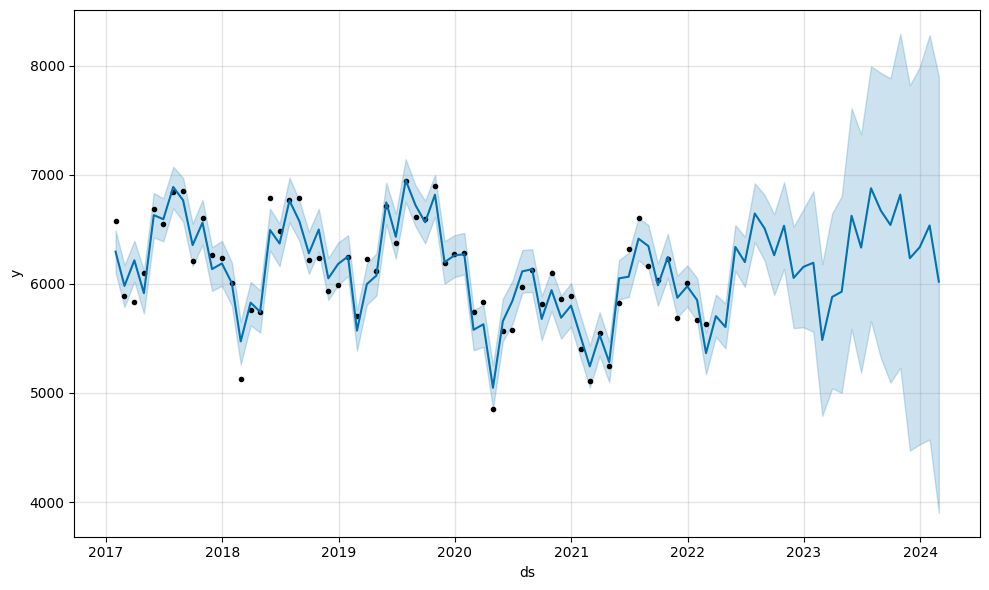

In [ ]:
fig1 =model_prophet_month.plot(prophet_predict)

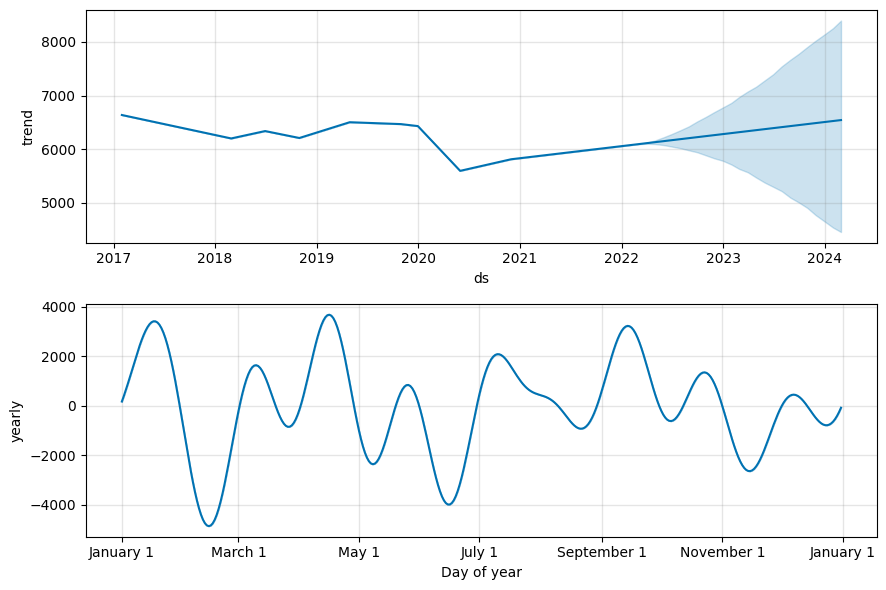

In [ ]:
# Plot the forecast components
fig2 = model_prophet_month.plot_components(prophet_predict)

In [ ]:
# Set index to date for merging and comparison
prophet_predict.set_index('ds', inplace=True)
validmonth_ts_df = pd.DataFrame(validmonth_ts)
validmonth_ts_df.index = validmonth_ts.index  # Ensure the index is set if not already

# Merge forecasts with actual validation data
prophet_merge_df = validmonth_ts_df.join(prophet_predict[['yhat', 'yhat_lower', 'yhat_upper']], how='inner')
prophet_merge_df


,MONTHLY_CRIME_COUNT,yhat,yhat_lower,yhat_upper
2022-03-31,6081,5704.674204,5515.680605,5902.425471
2022-04-30,6068,5604.801585,5407.901266,5820.282679
2022-05-31,6583,6339.421370,6119.384120,6538.682191
2022-06-30,6343,6200.219031,5970.808057,6431.772810
2022-07-31,6361,6645.892940,6383.760235,6922.184597
2022-08-31,6529,6508.778302,6211.938379,6815.949541
2022-09-30,6098,6263.209331,5897.762777,6637.198060
2022-10-31,6206,6533.499894,6138.027344,6932.124052
2022-11-30,5761,6055.133389,5595.202885,6523.756875
2022-12-31,5796,6156.574202,5602.223897,6685.838851


In [ ]:
import plotly.express as px

fig = px.line(prophet_merge_df, x=prophet_merge_df.index, y=['MONTHLY_CRIME_COUNT', 'yhat'],
              labels={'value': 'Crime Rate', 'variable': 'Legend'},
              title='Prophet Model Forecast vs Actual Data')

# Add range slider
fig.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(
            visible=True
        ),
        type="date"
    )
)

fig.show()

In [ ]:

prophet_predict_filtered = prophet_predict.loc[validmonth_ts.index, 'yhat']

# Now use the regressionSummary function
regressionSummary(validmonth_ts, prophet_predict_filtered)
validmonth_ts_df = pd.DataFrame(validmonth_ts)
validmonth_ts_df.index = validmonth_ts.index  # This step may be redundant if 'validmonth_ts' is already properly indexed

# If 'prophet_predict' already has 'ds' as its index
validation_predictions = prophet_predict.loc[validmonth_ts_df.index]


Regression statistics

                      Mean Error (ME) : 60.6034
       Root Mean Squared Error (RMSE) : 417.6642
            Mean Absolute Error (MAE) : 306.0064
          Mean Percentage Error (MPE) : 0.4246
Mean Absolute Percentage Error (MAPE) : 5.2032


In [ ]:
prophet_predict_filtered = prophet_predict.loc[validmonth_ts.index, 'yhat']

# Now use the regressionSummary function
regressionSummary(validmonth_ts, prophet_predict_filtered)
validmonth_ts_df = pd.DataFrame(validmonth_ts)
validmonth_ts_df.index = validmonth_ts.index  # This step may be redundant if 'validmonth_ts' is already properly indexed

# If 'prophet_predict' already has 'ds' as its index
validation_predictions = prophet_predict.loc[validmonth_ts_df.index]


Regression statistics

                      Mean Error (ME) : 60.6034
       Root Mean Squared Error (RMSE) : 417.6642
            Mean Absolute Error (MAE) : 306.0064
          Mean Percentage Error (MPE) : 0.4246
Mean Absolute Percentage Error (MAPE) : 5.2032


#### Daily Time Series Forecasting

##### Daily Time Series Preprocessing

In [ ]:
df_CMPD_ts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 530489 entries, 2024-02-22 to 2017-01-01
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   YEAR                       530489 non-null  int64 
 1   CMPD_PATROL_DIVISION       530489 non-null  object
 2   NPA                        530489 non-null  int64 
 3   LOCATION_TYPE_DESCRIPTION  530489 non-null  object
 4   PLACE_TYPE_DESCRIPTION     530489 non-null  object
 5   PLACE_DETAIL_DESCRIPTION   530489 non-null  object
 6   HIGHEST_NIBRS_CODE         530489 non-null  object
 7   MONTH                      530489 non-null  int64 
 8   DAY                        530489 non-null  object
 9   SEASON                     530489 non-null  object
 10  MONTHLY_CRIME_COUNT        530489 non-null  int64 
 11  DAILY_CRIME_COUNT          530489 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 52.6+ MB


In [ ]:
# Daily_Crime_Count' is the same for each day of a given month, take the first one
daily_ts = df_CMPD_ts['DAILY_CRIME_COUNT'].resample('D').first()

daily_ts.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 2609 entries, 2017-01-01 to 2024-02-22
Freq: D
Series name: DAILY_CRIME_COUNT
Non-Null Count  Dtype
--------------  -----
2609 non-null   int64
dtypes: int64(1)
memory usage: 40.8 KB


In [ ]:
daily_ts.head()

,DAILY_CRIME_COUNT
DATE_REPORTED,
2017-01-01,191
2017-01-02,185
2017-01-03,243
2017-01-04,247
2017-01-05,255


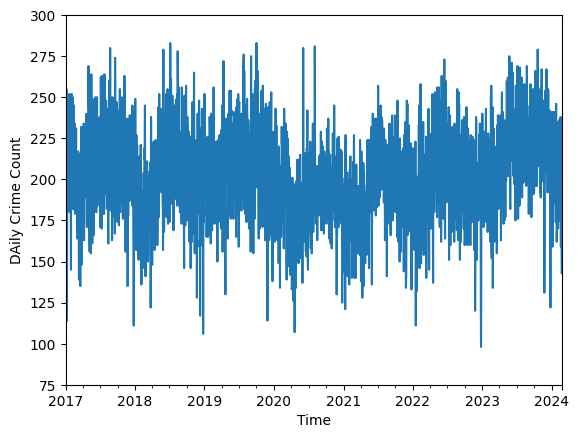

In [ ]:
ax =daily_ts.plot()
ax.set_xlabel('Time')
ax.set_ylabel('DAily Crime Count')
ax.set_ylim(75,300)
plt.show()

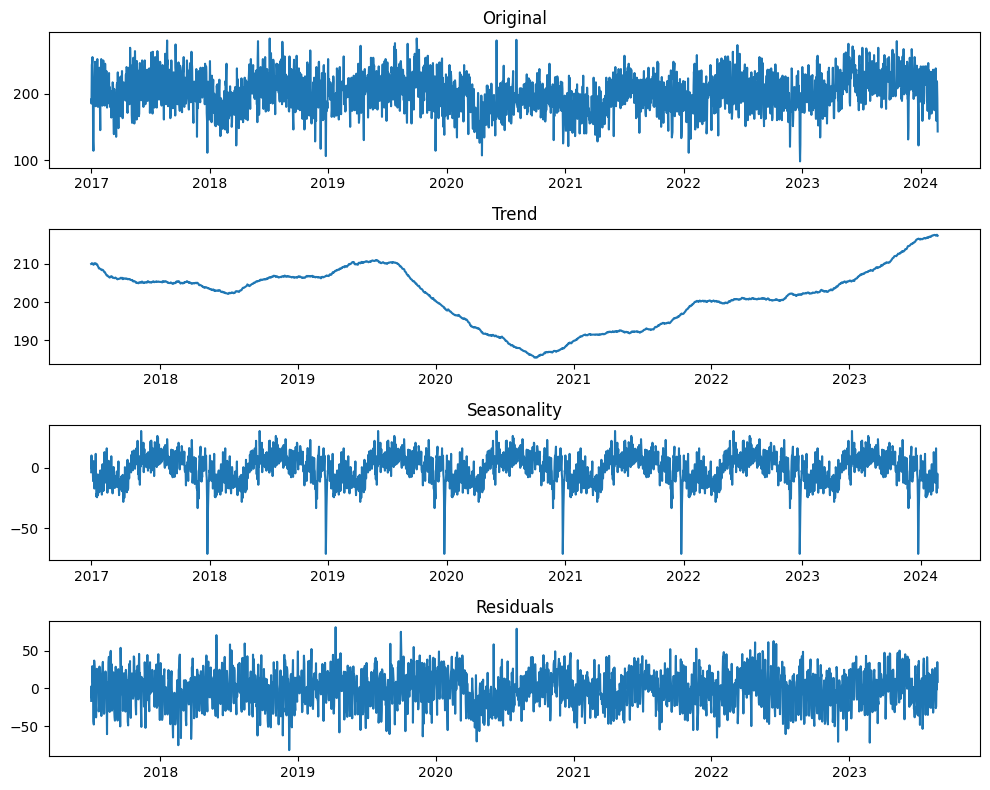

In [ ]:
decomposition = seasonal_decompose(daily_ts, model='additive', period =365)

# Plotting the decomposed components
fig, ax = plt.subplots(4, 1, figsize=(10, 8))
ax[0].plot(decomposition.observed)
ax[0].set_title('Original')
ax[1].plot(decomposition.trend)
ax[1].set_title('Trend')
ax[2].plot(decomposition.seasonal)
ax[2].set_title('Seasonality')
ax[3].plot(decomposition.resid)
ax[3].set_title('Residuals')
plt.tight_layout()
plt.show()

##### Daily Time Series using Prophet accounting for Covid

In [ ]:
daily_ts = pd.DataFrame(daily_ts)
daily_ts.reset_index(inplace=True)
daily_ts.rename(columns={'DATE_REPORTED': 'ds', 'DAILY_CRIME_COUNT': 'y'}, inplace=True)

In [ ]:
nValid_daily = 365
nTrain_daily = len(daily_ts) - nValid_daily
train_daily_ts = daily_ts[:nTrain_daily]
valid_daily_ts = daily_ts[nTrain_daily:]

In [ ]:
# COVID-19 period in North Carolina
covid_periods = pd.DataFrame({
    'holiday': 'nc_covid_lockdown',
    'ds': pd.to_datetime(['2020-03-15', '2022-08-15']),
    'lower_window': 0,
    'upper_window': 0,
})

# U.S. public holidays
from prophet.make_holidays import make_holidays_df
holidays_df = make_holidays_df(year_list=[2017, 2018, 2019, 2020, 2021, 2022, 2023], country='US')

# Combine the holiday and COVID periods
holidays = pd.concat([holidays_df, covid_periods])

In [ ]:
prophet_daily = Prophet(holidays=holidays)
prophet_daily.fit(train_daily_ts)

# Creating future dates for predictions covering the validation period
future_daily = prophet_daily.make_future_dataframe(periods=365)

# Predict
prophet_predict_daily = prophet_daily.predict(future_daily)

# Extract predictions corresponding to the validation set dates
forecast_valid = future_daily[-365:]

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsfk5y5lw/igvkugfx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsfk5y5lw/ednh8_yg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=84635', 'data', 'file=/tmp/tmpsfk5y5lw/igvkugfx.json', 'init=/tmp/tmpsfk5y5lw/ednh8_yg.json', 'output', 'file=/tmp/tmpsfk5y5lw/prophet_modeljp95ky6w/prophet_model-20240803233422.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:34:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:34:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
forecast_valid.head()

,ds
2244,2023-02-23
2245,2023-02-24
2246,2023-02-25
2247,2023-02-26
2248,2023-02-27


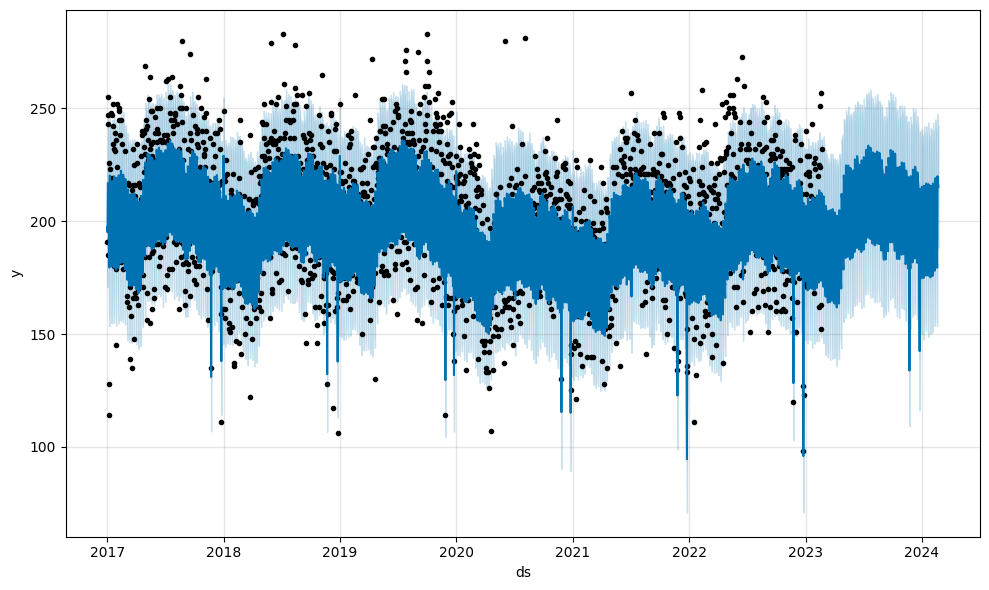

In [ ]:
fig2 =prophet_daily.plot(prophet_predict_daily)

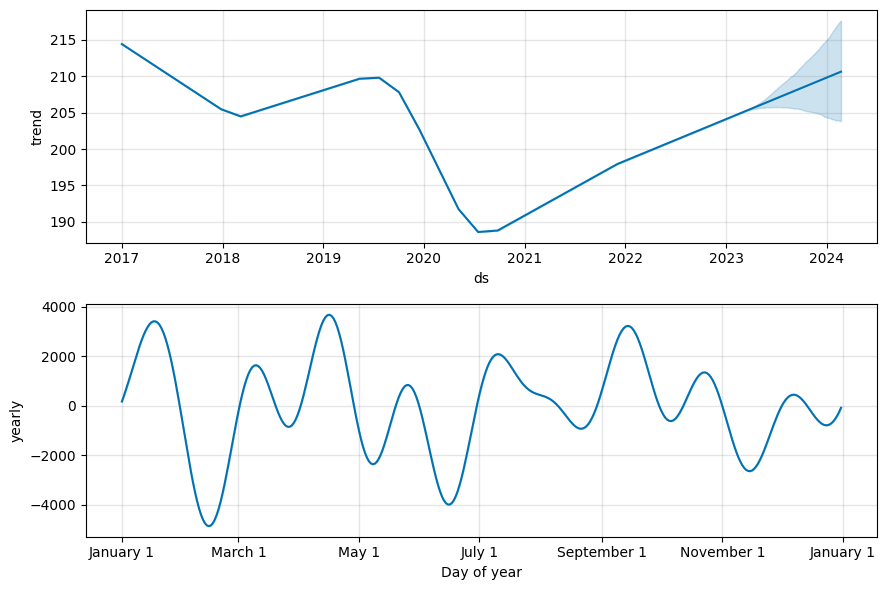

In [ ]:
fig2 = model_prophet_month.plot_components(prophet_predict_daily)

In [ ]:
prophet_predict_daily.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Christmas Day (observed),Christmas Day (observed)_lower,Christmas Day (observed)_upper,Columbus Day,Columbus Day_lower,Columbus Day_upper,Independence Day,Independence Day_lower,Independence Day_upper,Independence Day (observed),Independence Day (observed)_lower,Independence Day (observed)_upper,Juneteenth National Independence Day,Juneteenth National Independence Day_lower,Juneteenth National Independence Day_upper,Juneteenth National Independence Day (observed),Juneteenth National Independence Day (observed)_lower,Juneteenth National Independence Day (observed)_upper,Labor Day,Labor Day_lower,Labor Day_upper,Martin Luther King Jr. Day,Martin Luther King Jr. Day_lower,Martin Luther King Jr. Day_upper,Memorial Day,Memorial Day_lower,Memorial Day_upper,New Year's Day,New Year's Day_lower,New Year's Day_upper,New Year's Day (observed),New Year's Day (observed)_lower,New Year's Day (observed)_upper,Thanksgiving,Thanksgiving_lower,Thanksgiving_upper,Veterans Day,Veterans Day_lower,Veterans Day_upper,Veterans Day (observed),Veterans Day (observed)_lower,Veterans Day (observed)_upper,Washington's Birthday,Washington's Birthday_lower,Washington's Birthday_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,holidays_lower,holidays_upper,nc_covid_lockdown,nc_covid_lockdown_lower,nc_covid_lockdown_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-01,214.374481,171.946196,222.014332,214.374481,214.374481,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.270056,18.270056,18.270056,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-17.014558,-17.014558,-17.014558,18.270056,18.270056,18.270056,0.0,0.0,0.0,-27.138739,-27.138739,-27.138739,-8.145874,-8.145874,-8.145874,0.0,0.0,0.0,197.359923
1,2017-01-02,214.349666,170.835196,221.466543,214.349666,214.349666,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,-24.594511,-24.594511,-24.594511,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-19.261470,-19.261470,-19.261470,-24.594511,-24.594511,-24.594511,0.0,0.0,0.0,13.525725,13.525725,13.525725,-8.192684,-8.192684,-8.192684,0.0,0.0,0.0,195.088196
2,2017-01-03,214.324851,189.841719,241.144102,214.324851,214.324851,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.520207,2.520207,2.520207,0.000000,0.000000,0.000000,0.0,0.0,0.0,10.705747,10.705747,10.705747,-8.185540,-8.185540,-8.185540,0.0,0.0,0.0,216.845059
3,2017-01-04,214.300037,192.431582,246.437774,214.300037,214.300037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.476231,2.476231,2.476231,0.000000,0.000000,0.000000,0.0,0.0,0.0,10.607367,10.607367,10.607367,-8.131136,-8.131136,-8.131136,0.0,0.0,0.0,216.776267
4,2017-01-05,214.275222,191.218472,243.289056,214.275222,214.275222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.437742,1.437742,1.437742,0.000000,0.000000,0.000000,0.0,0.0,0.0,9.474939,9.474939,9.474939,-8.037198,-8.037198,-8.037198,0.0,0.0,0.0,215.712963


In [ ]:
prophet_predict_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2609 entries, 0 to 2608
Data columns (total 73 columns):
 #   Column                                                 Non-Null Count  Dtype         
---  ------                                                 --------------  -----         
 0   ds                                                     2609 non-null   datetime64[ns]
 1   trend                                                  2609 non-null   float64       
 2   yhat_lower                                             2609 non-null   float64       
 3   yhat_upper                                             2609 non-null   float64       
 4   trend_lower                                            2609 non-null   float64       
 5   trend_upper                                            2609 non-null   float64       
 6   Christmas Day                                          2609 non-null   float64       
 7   Christmas Day_lower                                    2609 non-null 

In [ ]:
valid_daily_ts_df = pd.DataFrame(valid_daily_ts)
valid_daily_ts_df.set_index('ds', inplace=True)

valid_daily_ts.head()

,ds,y
2244,2023-02-23,215
2245,2023-02-24,244
2246,2023-02-25,134
2247,2023-02-26,172
2248,2023-02-27,196


In [ ]:
prophet_predict_daily.set_index('ds', inplace=True)

In [ ]:
valid_daily_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 2244 to 2608
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      365 non-null    datetime64[ns]
 1   y       365 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.8 KB


In [ ]:
# Merge forecasts with actual validation data
prophet_mergeD_df = valid_daily_ts_df.join(prophet_predict_daily[['yhat', 'yhat_lower', 'yhat_upper']], how='inner')
prophet_mergeD_df.head()

,y,yhat,yhat_lower,yhat_upper
ds,,,,
2023-02-23,215,209.060288,185.790753,233.826072
2023-02-24,244,204.673878,179.085208,229.862837
2023-02-25,134,175.903159,151.704687,201.966490
2023-02-26,172,170.921983,145.917873,195.080890
2023-02-27,196,210.988274,187.337207,237.629764


In [ ]:
import plotly.graph_objects as go

# Create a Plotly graph object figure
fig = go.Figure()

# Add the actual data line
fig.add_trace(go.Scatter(x=prophet_mergeD_df.index, y=prophet_mergeD_df['y'],
                         mode='lines+markers',
                         name='Actual Crime Count',
                         line=dict(color='blue')))

# Add the forecasted data line
fig.add_trace(go.Scatter(x=prophet_mergeD_df.index, y=prophet_mergeD_df['yhat'],
                         mode='lines',
                         name='Forecasted Crime Count',
                         line=dict(color='red')))

# Add the forecasted range (confidence interval)
fig.add_trace(go.Scatter(x=prophet_mergeD_df.index.tolist() + prophet_mergeD_df.index[::-1].tolist(),
                         y=prophet_mergeD_df['yhat_upper'].tolist() + prophet_mergeD_df['yhat_lower'][::-1].tolist(),
                         fill='toself',
                         fillcolor='rgba(255, 0, 0, 0.2)',
                         line=dict(color='rgba(255, 255, 255, 0)'),
                         name='Forecast Confidence Interval'))

# Set plot layout
fig.update_layout(title='Prophet Model Forecast vs Actual Crime Data',
                  xaxis_title='Date',
                  yaxis_title='Crime Count',
                  xaxis=dict(rangeselector=dict(buttons=list([
                      dict(count=1, label="1m", step="month", stepmode="backward"),
                      dict(count=3, label="3m", step="month", stepmode="backward"),
                      dict(count=6, label="6m", step="month", stepmode="backward"),
                      dict(step="all")
                  ])),
                  rangeslider=dict(visible=True),
                  type="date"))

# Show plot
fig.show()

In [ ]:
if 'ds' in valid_daily_ts.columns:
    # Convert 'ds' to datetime and set as index
    valid_daily_ts['ds'] = pd.to_datetime(valid_daily_ts['ds'])
    valid_daily_ts.set_index('ds', inplace=True)
else:
    print("'ds' is not in the DataFrame columns.")

In [ ]:
if not isinstance(valid_daily_ts.index, pd.DatetimeIndex):
    valid_daily_ts.index = pd.to_datetime(valid_daily_ts.index)

In [ ]:
# Filter the predictions to only include the dates present in your validation set
prophet_predict_filtered = prophet_predict_daily.loc[valid_daily_ts.index, 'yhat']

In [ ]:
# merge the actual and predicted values into one DataFrame for comparison
comparison_df = valid_daily_ts_df.join(prophet_predict_filtered, how='inner', rsuffix='_predicted')


regressionSummary(comparison_df['y'], comparison_df['yhat'])

# If 'prophet_predict_daily' does not have 'ds' as its index, then reset it and use merge
if 'ds' not in prophet_predict_daily.columns:
    prophet_predict_daily.reset_index(inplace=True)

validation_predictions = prophet_predict_daily.loc[prophet_predict_daily['ds'].isin(valid_daily_ts_df.index)]


Regression statistics

                      Mean Error (ME) : 10.4208
       Root Mean Squared Error (RMSE) : 23.5608
            Mean Absolute Error (MAE) : 18.7248
          Mean Percentage Error (MPE) : 3.9863
Mean Absolute Percentage Error (MAPE) : 8.5194
